#**User Interview**

#**Part 1 - Business & Data Understanding**

##**Business Background**

Perusahaan merupakan bisnis hotel booking dan accommodation yang melayani berbagai tipe pelanggan melalui beragam market segment dan distribution channel. Dataset mencatat lebih dari 83 ribu booking dari proses reservasi hingga status akhir reservasi, sehingga perusahaan memiliki data yang cukup lengkap untuk memahami perilaku pelanggan, pola booking, serta faktor yang berkaitan dengan cancellation dan revenue.

Namun, dalam bisnis hospitality, jumlah booking saja tidak cukup untuk menggambarkan performa bisnis. Booking yang tinggi tetapi memiliki tingkat cancellation yang tinggi dapat menciptakan revenue uncertainty, menyebabkan kamar tidak terjual kembali, dan menyulitkan hotel dalam melakukan inventory serta capacity planning.

Di sisi lain, karakteristik pelanggan juga berbeda-beda. Pelanggan dengan lead time panjang, pelanggan baru, repeat guest, market segment tertentu, maupun pelanggan yang menggunakan distribution channel tertentu dapat memiliki tingkat cancellation dan nilai transaksi yang berbeda. Perbedaan tersebut berpotensi memengaruhi keputusan hotel dalam menentukan strategi booking, deposit, pricing, channel management, dan customer retention.

Karena itu, perusahaan membutuhkan analisis yang tidak hanya melihat berapa banyak booking yang terjadi, tetapi juga memahami kualitas booking, risiko cancellation, potensi revenue yang hilang, dan karakteristik pelanggan yang berada di balik pola tersebut

##**Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries Successfully Imported")

Libraries Successfully Imported


##**Connect Google Drive**

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


##**Load Dataset**

In [3]:
df = pd.read_csv('/content/drive/MyDrive/User Interview/train.csv')

print("Dataset Successfully Loaded")

Dataset Successfully Loaded


##**Basic Information**

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)

display(df.head())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)

display(df.dtypes)

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

Dataset Shape:
(83293, 33)

FIRST 5 ROWS


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,0.000,0,BB,ITA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,314.000,NaN,0,Transient,38.400,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,0.000,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,1.000,NaN,0,Transient,62.800,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,0.000,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,12.000,NaN,0,Transient,110.000,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,0.000,0,BB,NaN,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,200.000,0,Transient,45.000,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,0.000,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,16.000,NaN,0,Transient,57.920,0,1,Canceled,2017-08-24,5



DATA TYPES


,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal       

Hasil pengecekan menunjukkan bahwa dataset memiliki **83.293 baris dan 33 kolom**. Lima data pertama menunjukkan bahwa setiap baris merepresentasikan satu reservasi hotel dengan berbagai informasi terkait booking, tamu, tanggal kedatangan, tipe kamar, hingga harga kamar. Dataset terdiri dari data **numerik dan kategorikal**, dengan beberapa kolom seperti children, country, agent, dan company yang memiliki **missing value**


##**Statistical Summary**

In [5]:
print("Numerical Variables Summary:")

display(df.describe().T)

Numerical Variables Summary:


,count,mean,std,min,25%,50%,75%,max
is_canceled,83293.000,0.370,0.483,0.000,0.000,0.000,1.000,1.000
lead_time,83293.000,103.914,106.874,0.000,18.000,69.000,160.000,737.000
arrival_date_year,83293.000,2018.157,0.707,2017.000,2018.000,2018.000,2019.000,2019.000
arrival_date_week_number,83293.000,27.164,13.624,1.000,16.000,27.000,38.000,53.000
arrival_date_day_of_month,83293.000,15.786,8.776,1.000,8.000,16.000,23.000,31.000
stays_in_weekend_nights,83293.000,0.930,1.004,0.000,0.000,1.000,2.000,19.000
stays_in_week_nights,83293.000,2.504,1.925,0.000,1.000,2.000,3.000,50.000
adults,83293.000,1.854,0.606,0.000,2.000,2.000,2.000,55.000
children,83290.000,0.104,0.399,0.000,0.000,0.000,0.000,10.000
babies,83293.000,0.008,0.101,0.000,0.000,0.000,0.000,10.000


In [6]:
print("Categorical Variables Summary:")

display(df.describe(include='object').T)

Categorical Variables Summary:


,count,unique,top,freq
hotel,83293,64,Renaissance New York Times Square Hotel New Yo...,1373
arrival_date_month,83293,12,August,9643
meal,83293,5,BB,64424
country,82947,165,PRT,33952
market_segment,83293,8,Online TA,39445
distribution_channel,83293,5,TA/TO,68368
reserved_room_type,83293,10,A,60062
assigned_room_type,83293,11,A,51702
deposit_type,83293,3,No Deposit,72979
customer_type,83293,4,Transient,62535


Hasil memberikan ringkasan statistik untuk variabel numerik dalam dataset, seperti **jumlah data (count), nilai rata-rata (mean), standar deviasi (std), nilai minimum (min), kuartil (25%, 50%, 75%), dan maksimum (max)**. Ringkasan ini digunakan untuk melihat **distribusi, rentang, serta karakteristik dasar** dari setiap variabel numerik sehingga dapat membantu mengidentifikasi nilai yang tidak wajar atau outlier sebelum dilakukan analisis lebih lanjut

##**Missing Value**

In [7]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() / df.shape[0]) * 100
})
missing = missing[missing['missing_count']>0] \
.sort_values('missing_percentage', ascending=False)

print("Missing Value Summary:")
display(missing)

Missing Value Summary:


,missing_count,missing_percentage
company,78559,94.316
agent,11404,13.691
country,346,0.415
children,3,0.004


##**Duplicate Check**

In [8]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


##Unique Value Check

In [9]:
categorical_columns = df.select_dtypes(include='object').columns

unique_summary = pd.DataFrame({
    'column': categorical_columns,
    'unique_values': [df[col].nunique() for col in categorical_columns]
}).sort_values('unique_values', ascending=False)

display(unique_summary)

,column,unique_values
11,reservation_status_date,914
3,country,165
0,hotel,64
1,arrival_date_month,12
7,assigned_room_type,11
6,reserved_room_type,10
4,market_segment,8
2,meal,5
5,distribution_channel,5
9,customer_type,4


##**Target Variable Check**

In [10]:
cancellation_summary = df['is_canceled'].value_counts().to_frame('count')

cancellation_summary['percentage'] = (
    cancellation_summary['count'] / len(df) * 100)

display(cancellation_summary)

,count,percentage
is_canceled,,
0,52516,63.050
1,30777,36.950


##**Business Problem**

Masalah utama yang ingin dianalisis adalah ketidakpastian revenue akibat cancellation dan perbedaan perilaku pelanggan di berbagai booking channel

Perusahaan memiliki jumlah booking yang besar, tetapi tidak semua booking memberikan revenue yang terealisasi. Cancellation dapat terjadi setelah reservasi dibuat, sementara semakin panjang jarak antara waktu booking dan arrival, semakin panjang pula periode ketidakpastian inventory kamar

Selain itu, cancellation kemungkinan tidak terjadi secara acak. Risiko tersebut dapat berkaitan dengan kombinasi beberapa faktor seperti lead time, customer type, market segment, distribution channel, deposit type, previous cancellation behavior, hotel, ADR, room type, dan booking characteristics

Jika perusahaan hanya menggunakan satu aturan umum untuk seluruh pelanggan, perusahaan berisiko melakukan over-control terhadap pelanggan berisiko rendah atau sebaliknya memberikan fleksibilitas terlalu besar kepada pelanggan dengan cancellation risk tinggi

Dengan demikian, perusahaan membutuhkan pendekatan berbasis data untuk menemukan pola risiko cancellation, revenue exposure, dan customer/channel behavior, sehingga strategi booking dan revenue management dapat dibuat lebih targeted

##**Problem Steatment**



1.   Faktor apa saja yang paling membedakan booking yang berhasil terealisasi dengan booking yang mengalami cancellation, dan bagaimana kombinasi faktor tersebut membentuk profil booking dengan cancellation risk tinggi?
2.   Seberapa besar potensi revenue yang terekspos akibat cancellation, dan segmen pelanggan, hotel, atau booking channel mana yang memberikan kontribusi terbesar terhadap revenue yang berisiko hilang?
3.   Bagaimana hubungan antara lead time, customer type, repeat guest behavior, previous cancellation history, dan booking characteristics terhadap kemungkinan terjadinya cancellation?
4.   Apakah market segment dan distribution channel yang menghasilkan volume booking tinggi juga menghasilkan booking dengan kualitas yang baik, atau justru memiliki cancellation risk dan revenue exposure yang lebih tinggi?
5.   Dapatkah pelanggan atau booking dikelompokkan berdasarkan karakteristik value dan cancellation behavior untuk menentukan strategi yang berbeda dalam pricing, deposit policy, promotion, dan inventory management?




##**Busienss Objective**



*   Mengidentifikasi faktor utama yang berkaitan dengan cancellation untuk memahami karakteristik booking yang memiliki risiko pembatalan tinggi
*   Mengukur revenue exposure akibat cancellation sehingga perusahaan dapat mengetahui area bisnis yang memiliki potensi kehilangan revenue terbesar
*   Menganalisis hubungan antara lead time, customer behavior, market segment, dan distribution channel terhadap kualitas dan outcome booking
*   Mengevaluasi performa setiap market segment dan distribution channel tidak hanya berdasarkan booking volume, tetapi juga berdasarkan cancellation behavior dan revenue contribution
*  Membangun customer/booking segmentation berbasis behavioral dan transactional characteristics untuk menemukan kelompok dengan karakteristik value dan cancellation risk yang berbeda
*   Memberikan rekomendasi strategi yang lebih targeted terkait deposit policy, promotion, channel strategy, pricing, dan inventory management



##**Data Understanding**

Dataset yang digunakan adalah Dataset UserInterview DA dalam bentuk train.csv. Berdasarkan pemeriksaan awal, dataset terdiri dari 83.293 baris dan 33 kolom. Data merepresentasikan aktivitas booking hotel, mulai dari karakteristik reservasi, customer profile, channel, room, pricing, hingga reservation outcome

Dataset memiliki 83.293 observasi dan 33 variabel, dengan kombinasi data numerik, kategorikal, dan tanggal. Tidak ditemukan duplicate row pada pemeriksaan awal

Terdapat missing values pada beberapa variabel. company memiliki missing value yang sangat besar, yaitu 78.559, sedangkan agent memiliki 11.404 missing values. Variabel country memiliki 346 missing values dan children hanya 3 missing values. Missing value ini perlu dianalisis terlebih dahulu karena missing pada agent/company belum tentu berarti data error; bisa saja menunjukkan booking tidak melalui agent atau company tertentu. Jadi nanti jangan langsung kita drop

#**Part 2 - Data Preprocessing**

##**Check Duplicate**

In [11]:
df.duplicated().sum()

np.int64(0)

Hasil pemeriksaan dataset menunjukkan tidak terdapat duplicate rows

Karena itu, kita tidak perlu melakukan penghapusan duplicate

##**Check Missing Value**

In [12]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[
    missing_summary['Missing Count'] > 0
].sort_values(
    'Missing Percentage',
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
company,78559,94.316
agent,11404,13.691
country,346,0.415
children,3,0.004


Tidak langsung melakukan dropna() karena terlalu berbahaya, akan tetapi akan di lakukan proses handling secara terpisah

###**Handling Company**

In [13]:
df['company'] = df['company'].fillna(0)

In [14]:
df['has_comapny'] = np.where(df['company'] == 0, 0, 1)

Karena tidak menganggap missing company sebagai error

maka diubah ubah menjadi:

*   0 = booking tidak terkait company
*   1 = booking memiliki company

Feature has_company nantinya bisa membantu melihat apakah corporate-related booking memiliki cancellation behavior yang berbeda.

Ini akan relevan dengan Problem Statement #4 mengenai market segment dan distribution channel

###**Handling Agent**

In [15]:
df['agent'] = df['agent'].fillna(0)

df['has_agent'] = np.where(df['agent'] == 0, 0, 1)

Interpretasi :


*   0 = tidak menggunakan agent
*   1 = menggunakan agent

Karena tidak hanya ingin mengetahui berapa banyak booking dari sebuah channel, akan tetapi juga apakah booking melalui agent memiliki karakteristik canccelation dan juga revenue exposure yang berbeda



###**Handling Country**

In [16]:
df['country'] = df['country'].fillna('Unknown')

Menggunakan 'Unknown' akan lebih aman dibandingkan dengan mengisi dengan negara tertentu, karena tidak boleh membuat informasi geografis yang sebenarnya tidak ada

###**Handling Children**

In [17]:
df['children'] = df['children'].fillna(0)

Karena children merupakan jumlah anak dan juga secara bisnis 0 children adalah nilai yang masuk akal, maka ketika tidak ada informasi jumlah anak, bisa disii dengan 0

####Ubah Menjadi Integer

In [18]:
df['children'] = df['children'].astype(int)

##**Check Logical Inconsistency**

In [19]:
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

In [20]:
print("Bookings with zero total guests:")

display(df[df['total_guests'] == 0])

Bookings with zero total guests:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,has_comapny,has_agent,total_guests
1377,Sheraton Grand Rio Hotel & Resort Rio de Janei...,0,37,2018,November,47,17,1,3,0,0,0,SC,BRA,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9.000,0.000,0,Transient,97.400,1,1,Check-Out,2018-11-21,1378,0,1,0
1726,Protea Hotel by Marriott Cape Town Sea Point C...,0,31,2018,December,53,27,2,8,0,0,0,BB,PRT,Direct,Direct,0,0,0,D,D,3,No Deposit,0.000,0.000,0,Transient,28.000,1,0,Check-Out,2019-01-06,1727,0,0,0
1991,Sheraton Mexico City Maria Isabel Hotel Mexico...,0,0,2019,February,9,27,0,0,0,0,0,BB,PRT,Online TA,TA/TO,1,0,0,A,K,0,No Deposit,85.000,0.000,0,Transient,0.000,0,0,Check-Out,2019-02-27,1992,0,1,0
2036,Baton Rouge Acadian Centre/LSU Area Courtyard ...,0,0,2017,August,33,10,9,20,0,0,0,SC,PRT,Online TA,Direct,0,0,0,E,K,20,No Deposit,0.000,47.000,0,Transient,0.000,0,0,Check-Out,2017-09-08,2037,1,0,0
2401,"Orlando Airport Courtyard Orlando, FL",0,0,2017,December,52,24,0,0,0,0,0,BB,FRA,Offline TA/TO,TA/TO,1,0,0,D,K,0,No Deposit,28.000,0.000,0,Transient,0.000,0,1,Check-Out,2017-12-24,2402,0,1,0
3724,"Grosvenor House, A JW Marriott Hotel London, U...",0,0,2018,November,48,26,0,0,0,0,0,BB,PRT,Offline TA/TO,TA/TO,1,0,0,A,D,0,No Deposit,28.000,0.000,0,Transient,0.000,0,0,Check-Out,2018-11-26,3725,0,1,0
3743,Protea Hotel by Marriott Cape Town Sea Point C...,0,0,2018,December,50,5,0,0,0,0,0,BB,PRT,Offline TA/TO,TA/TO,1,0,0,A,K,0,No Deposit,27.000,0.000,0,Transient,0.000,0,0,Check-Out,2018-12-05,3744,0,1,0
4770,"Crystal Cove, Barbados Barbados",0,0,2017,August,33,11,2,10,0,0,0,SC,ITA,Corporate,Corporate,0,0,0,A,K,11,No Deposit,0.000,38.000,0,Group,0.000,0,0,Check-Out,2017-08-23,4771,1,0,0
5047,Renaissance New York Times Square Hotel New Yo...,0,88,2018,August,34,16,0,4,0,0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,K,5,No Deposit,9.000,0.000,0,Transient,32.850,0,2,Check-Out,2018-08-20,5048,0,1,0
5567,Baton Rouge Acadian Centre/LSU Area Courtyard ...,0,36,2018,August,35,27,3,6,0,0,0,SC,ESP,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,9.000,0.000,0,Transient,89.200,0,2,Check-Out,2018-09-05,5568,0,1,0


Kita tidak hanya mengecek missing value, tetapi juga apakah terdapat booking yang secara logika tidak masuk akal

Booking dengan total guest = 0 perlu ditinjau karena secara bisnis tidak masuk akal jika terdapat reservasi tetapi tidak ada guest

Jangan langsung delete sebelum melihat kaitannya dengan cancellation

In [21]:
zero_guest_summary = (
    df[df['total_guests'] == 0]
    .groupby('is_canceled')
    .size()
    .reset_index(name='booking_count')
)

display(zero_guest_summary)

,is_canceled,booking_count
0,0,111
1,1,16


Berdasarkan hasil **checking logical inconsistency**, ditemukan **127 booking dengan total_guests = 0**, yang terdiri dari **111 booking tidak dibatalkan is_canceled = 0 dan 16 booking dibatalkan is_canceled = 1**. Kondisi ini merupakan anomali karena secara logika sebuah reservasi seharusnya memiliki minimal satu tamu. Menariknya, mayoritas booking tersebut justru berstatus tidak dibatalkan, sehingga anomali ini **tidak dapat langsung diasumsikan sebagai booking cancellation**. Karena itu, data perlu dipertahankan terlebih dahulu untuk ditelusuri lebih lanjut, terutama apakah nilai nol tersebut berasal dari kesalahan input atau karakteristik tertentu dalam proses reservasi.


##**Create Stay Features**

In [22]:
df['total_stay_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

In [23]:
def categorize_stay(nights):
    if nights == 0:
        return 'No Stay'
    elif nights <= 2:
        return 'Short Stay'
    elif nights <= 5:
        return 'Medium Stay'
    else:
        return 'Long Stay'

df['stay_category'] = df['total_stay_nights'].apply(categorize_stay)

Ini nantinya berguna untuk melihat apakah booking dengan durasi tinggal berbeda mempunyai cancellation behavior dan revenue contribution yang berbeda

##**Create Revenue Features**

In [24]:
df['estimated_revenue'] = (df['adr'] *
    df['total_stay_nights']
)

In [25]:
df['revenue_status'] = np.where(
    df['is_canceled'] == 1,
    'At Risk',
    'Realized'
)

Interpretasinya
*   Realizeed = bookig tidak cancelled
*   At Risk = Bookining Canncelled dan juga nilai booking dianggap sebagai revenue exporsure


Catatan penting: estimated_revenue adalah estimasi berbasis ADR dan lama menginap, bukan revenue accounting aktual. Jadi nanti saat presentasi kita akan menyebutnya estimated revenue exposure, bukan actual lost revenue


##Create Customer Behavior Features

In [26]:
df['total_previous_bookings'] = (
    df['previous_cancellations'] +
    df['previous_bookings_not_canceled']
)

In [27]:
df['historical_cancellation_rate'] = np.where(
    df['total_previous_bookings'] > 0,
    df['previous_cancellations'] /
    df['total_previous_bookings'],
    0
)

Customer dengan 2 previous cancellations dari 2 historical bookings ≠ customer dengan 2 previous cancellations dari 20 historical bookings

##**Create Customer Behavior Category**

In [28]:
def customer_history_category(row):

    if row['total_previous_bookings'] == 0:
        return 'New Customer'

    elif row['historical_cancellation_rate'] >= 0.5:
        return 'High Cancellation History'

    elif row['historical_cancellation_rate'] > 0:
        return 'Some Cancellation History'

    else:
        return 'Reliable Returning Customer'


df['customer_history_category'] = df.apply(
    customer_history_category,
    axis=1
)

##**Create Lead Time Category**

In [29]:
def lead_time_category(days):

    if days <= 7:
        return 'Last Minute'

    elif days <= 30:
        return 'Short Lead Time'

    elif days <= 90:
        return 'Medium Lead Time'

    elif days <= 180:
        return 'Long Lead Time'

    else:
        return 'Very Long Lead Time'


df['lead_time_category'] = df['lead_time'].apply(
    lead_time_category
)

Kategori ini nantinya akan dibandingkan dengan:


*   cancellation rate
*   estimated revenue exposure
*   customer type
*   market segment
*   distribution channel




##**Create Booking Modification Feature**

In [30]:
df['has_booking_changes'] = np.where(
    df['booking_changes'] > 0,1,0)

In [31]:
def booking_change_category(changes):

    if changes == 0:
        return 'No Changes'

    elif changes == 1:
        return 'One Change'

    else:
        return 'Multiple Changes'


df['booking_change_category'] = (
    df['booking_changes']
    .apply(booking_change_category)
)

Ini akan berguna untuk melihat apakah booking yang lebih sering berubah juga memiliki outcome yang berbeda

##**Create Special Request Feature**

In [32]:
df['has_special_requests'] = np.where(
    df['total_of_special_requests'] > 0,1,0)

In [33]:
def special_request_category(requests):

    if requests == 0:
        return 'No Request'

    elif requests == 1:
        return 'Low'

    else:
        return 'High'


df['special_request_category'] = (
    df['total_of_special_requests']
    .apply(special_request_category)
)

Feature ini bukan core cancellation feature, tetapi dapat membantu customer behavior segmentation

##**Create Room Change Feature**

In [34]:
df['room_type_change'] = np.where(
    df['reserved_room_type'] != df['assigned_room_type'],1,0)



*   0 = assigned room sesuai reserved room
*   1 = terjadi perubahan room type

Ini dapat menjadi variabel tambahan untuk memahami booking experience dan reservation outcome



##**Create Cancellation Risk Proxy**

In [35]:
df['high_lead_time_flag'] = np.where(
    df['lead_time'] > df['lead_time'].median(),1,0)

df['previous_cancel_flag'] = np.where(
    df['previous_cancellations'] > 0,1,0)

df['long_waiting_flag'] = np.where(
    df['days_in_waiting_list'] > 0,1,0)

Ini bukan prediction

Ini hanya indikator perilaku yang nantinya akan kita uji hubungannya dengan is_canceled

##**Create Date Feature**

In [36]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [37]:
df['reservation_year'] = (
    df['reservation_status_date'].dt.year
)

df['reservation_month'] = (
    df['reservation_status_date'].dt.month
)

df['reservation_day'] = (
    df['reservation_status_date'].dt.day
)

df['reservation_dayofweek'] = (
    df['reservation_status_date'].dt.dayofweek
)

In [38]:
df['reservation_month_name'] = (
    df['reservation_status_date'].dt.month_name())

##**Create Arrival Date**

In [39]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month']
    + '-' + df['arrival_date_day_of_month'].astype(str), format='%Y-%B-%d',errors='coerce')

In [40]:
print("Invalid arrival dates:", df['arrival_date'].isna().sum())

Invalid arrival dates: 65


In [41]:
invalid_arrivals = df[df['arrival_date'].isna()][
    ['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month']]

invalid_arrivals

,arrival_date_year,arrival_date_month,arrival_date_day_of_month
1565,2018,February,29
3069,2018,February,29
3081,2018,February,29
3792,2018,February,29
4488,2018,February,29
5330,2018,February,29
5420,2018,February,29
5488,2018,February,29
6445,2018,February,29
7270,2018,February,29


In [42]:
# Perbaiki tanggal 29 Februari 2018 yang tidak valid
mask = (
    (df['arrival_date_year'] == 2018) &
    (df['arrival_date_month'] == 'February') &
    (df['arrival_date_day_of_month'] == 29)
)

df.loc[mask, 'arrival_date_day_of_month'] = 28

In [43]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

print("Invalid arrival dates:", df['arrival_date'].isna().sum())

Invalid arrival dates: 0


Kalau 0, berarti seluruh kombinasi tanggal berhasil dikonversi

##**Create Arrival Time Features**

In [44]:
df['arrival_year'] = df['arrival_date'].dt.year

df['arrival_month_num'] = df['arrival_date'].dt.month

df['arrival_month_name'] = df['arrival_date'].dt.month_name()

df['arrival_dayofweek'] = (df['arrival_date'].dt.dayofweek)

In [45]:
df['is_arrival_weekend'] = np.where(
    df['arrival_dayofweek'].isin([5, 6]),1,0)

Ini bisa membantu analisis seasonality dan booking pattern

##**Create Total Nights + ADR Revenue Logic**

In [46]:
print("ADR < 0:", (df['adr'] < 0).sum())
print("Total nights < 0:", (df['total_stay_nights'] < 0).sum())
print("Estimated revenue < 0:", (df['estimated_revenue'] < 0).sum())

ADR < 0: 0
Total nights < 0: 0
Estimated revenue < 0: 0


Hasil pengecekan menunjukkan bahwa data sudah aman untuk dilanjutkan ke tahap berikutnya. Berdasarkan hasil validasi, **tidak ditemukan nilai ADR yang negatif, total nights yang negatif, maupun estimated revenue yang negatif**. Hal ini ditunjukkan oleh seluruh hasil pengecekan yang bernilai **0**, sehingga tidak terdapat data yang perlu diinvestigasi atau dilakukan treatment terkait nilai negatif. Dengan demikian, perhitungan **Total Nights, ADR, dan Estimated Revenue** dapat digunakan untuk proses analisis selanjutnya.


##**Check Outliers**

In [47]:
numeric_columns = [
    'lead_time',
    'adr',
    'adults',
    'children',
    'babies',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'column': col,
        'Q1': Q1,
        'Q3': Q3,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outliers,
        'outlier_percentage': outliers / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(
    outlier_summary
    .sort_values('outlier_percentage', ascending=False)
)

,column,Q1,Q3,lower_bound,upper_bound,outlier_count,outlier_percentage
2,adults,2.000,2.000,2.000,2.000,20920,25.116
9,booking_changes,0.000,0.000,0.000,0.000,12703,15.251
3,children,0.000,0.000,0.000,0.000,5961,7.157
11,required_car_parking_spaces,0.000,0.000,0.000,0.000,5109,6.134
7,previous_cancellations,0.000,0.000,0.000,0.000,4397,5.279
1,adr,69.530,126.000,-15.175,210.705,2672,3.208
10,days_in_waiting_list,0.000,0.000,0.000,0.000,2594,3.114
8,previous_bookings_not_canceled,0.000,0.000,0.000,0.000,2532,3.040
6,stays_in_week_nights,1.000,3.000,-2.000,6.000,2355,2.827
0,lead_time,18.000,160.000,-195.000,373.000,2112,2.536


Berdasarkan hasil deteksi menggunakan metode IQR (Interquartile Range), ditemukan beberapa nilai outlier pada sejumlah variabel, seperti adults, booking_changes, children, required_car_parking_spaces, previous_cancellations, adr, dan lead_time. Namun, outlier tersebut tidak langsung dihapus atau diubah, karena nilai ekstrem belum tentu merupakan kesalahan data dan masih dapat merepresentasikan kondisi nyata dalam pola pemesanan hotel. Hal ini terutama penting karena project berfokus pada revenue exposure dan cancellation risk, sehingga nilai ekstrem seperti lead_time yang tinggi justru berpotensi memberikan informasi penting mengenai perilaku pelanggan dan kemungkinan pembatalan. Oleh karena itu, prinsip treatment yang digunakan adalah “outlier = investigated first, not automatically removed”. Dengan pendekatan ini, data tetap dipertahankan selama tidak terbukti sebagai error, sehingga informasi bisnis yang terkandung dalam observasi ekstrem tidak hilang dari analisis

##**Final Data Quantity Check**

In [48]:
print("Dataset shape after cleaning:")
print(df.shape)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape after cleaning:
(83293, 63)

Missing values:


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0



Duplicate rows:
0


In [49]:
new_features = [
    'has_comapny',
    'has_agent',
    'total_guests',
    'total_stay_nights',
    'stay_category',
    'estimated_revenue',
    'revenue_status',
    'total_previous_bookings',
    'historical_cancellation_rate',
    'customer_history_category',
    'lead_time_category',
    'has_booking_changes',
    'booking_change_category',
    'has_special_requests',
    'special_request_category',
    'room_type_change',
    'high_lead_time_flag',
    'previous_cancel_flag',
    'long_waiting_flag',
    'arrival_date',
    'arrival_year',
    'arrival_month_num',
    'arrival_month_name',
    'arrival_dayofweek',
    'is_arrival_weekend'
]

display(df[new_features].head())

,has_comapny,has_agent,total_guests,total_stay_nights,stay_category,estimated_revenue,revenue_status,total_previous_bookings,historical_cancellation_rate,customer_history_category,lead_time_category,has_booking_changes,booking_change_category,has_special_requests,special_request_category,room_type_change,high_lead_time_flag,previous_cancel_flag,long_waiting_flag,arrival_date,arrival_year,arrival_month_num,arrival_month_name,arrival_dayofweek,is_arrival_weekend
0,0,1,2,4,Medium Stay,153.600,Realized,0,0.000,New Customer,Short Lead Time,0,No Changes,0,No Request,0,0,0,0,2019-01-10,2019,1,January,3,0
1,0,1,2,2,Short Stay,125.600,At Risk,0,0.000,New Customer,Very Long Lead Time,0,No Changes,0,No Request,0,1,0,0,2018-12-15,2018,12,December,5,1
2,0,1,2,3,Medium Stay,330.000,At Risk,0,0.000,New Customer,Long Lead Time,0,No Changes,0,No Request,0,1,0,0,2019-05-19,2019,5,May,6,1
3,1,0,1,1,Short Stay,45.000,Realized,0,0.000,New Customer,Last Minute,0,No Changes,0,No Request,0,0,0,0,2018-10-17,2018,10,October,2,0
4,0,1,2,5,Medium Stay,289.600,At Risk,0,0.000,New Customer,Medium Lead Time,0,No Changes,1,Low,0,0,0,0,2017-09-26,2017,9,September,1,0


##**Save Clean Dataset**

In [50]:
output_path = (
    '/content/drive/MyDrive/'
    'User Interview/'
    'hotel_booking_cleaned.csv'
)

df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset successfully saved.")
print(output_path)

Cleaned dataset successfully saved.
/content/drive/MyDrive/User Interview/hotel_booking_cleaned.csv


#**EDA Dan Visualisai**

EDA dilakukan untuk menemukan pola awal yang dapat menjelaskan mengapa cancellation terjadi, faktor apa yang berkaitan dengan cancellation, seberapa besar revenue exposure yang ditimbulkan, serta bagaimana perilaku pelanggan dan booking channel berbeda satu sama lain.

Analisis akan dimulai dari distribusi dan kondisi umum dataset, kemudian dilanjutkan dengan analisis cancellation, hubungan antarvariabel, revenue exposure, customer behavior, dan channel performance

In [51]:
# Soft Pastel Color Palette
soft_palette = [
    '#A8C3BC',  # Sage
    '#C9B8D9',  # Lavender
    '#F2C6B4',  # Peach
    '#B8CCE0',  # Soft Blue
    '#E6D5A8',  # Soft Beige
    '#D9B8B8',  # Dusty Rose
    '#BFD8D2',  # Mint
    '#D5C4A1'   # Sand
]

In [52]:
sns.set_theme(
    style="whitegrid",
    font_scale=1.05
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [53]:
category_colors = [
    '#A8C3BC',
    '#C9B8D9',
    '#F2C6B4',
    '#B8CCE0',
    '#E6D5A8',
    '#D9B8B8'
]

In [54]:
cancellation_colors = {
    0: '#A8C3BC',
    1: '#D9B8B8'
}

##**Descriptive Statics**

In [55]:
numeric_features = [
    'lead_time',
    'adr',
    'total_stay_nights',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'total_of_special_requests'
]

descriptive_stats = (df[numeric_features].describe().T)

descriptive_stats['median'] = (df[numeric_features].median())

descriptive_stats['variance'] = (df[numeric_features].var())

display(descriptive_stats[['count', 'mean', 'median', 'std', 'min', 'max', 'variance']].round(2))

,count,mean,median,std,min,max,variance
lead_time,83293.000,103.910,69.000,106.870,0.000,737.000,11422.080
adr,83293.000,101.720,94.500,48.080,0.000,508.000,2311.930
total_stay_nights,83293.000,3.430,3.000,2.580,0.000,69.000,6.650
previous_cancellations,83293.000,0.090,0.000,0.860,0.000,26.000,0.740
previous_bookings_not_canceled,83293.000,0.140,0.000,1.550,0.000,70.000,2.420
booking_changes,83293.000,0.220,0.000,0.660,0.000,21.000,0.430
days_in_waiting_list,83293.000,2.350,0.000,17.820,0.000,391.000,317.580
total_of_special_requests,83293.000,0.570,0.000,0.790,0.000,5.000,0.630


Median ditambahkan karena beberapa variabel memiliki distribusi yang sangat skewed. Perbedaan mean dan median ini mengindikasikan adanya distribusi yang tidak simetris dan observasi dengan lead time sangat panjang

##**Distribution Lead Of Time**

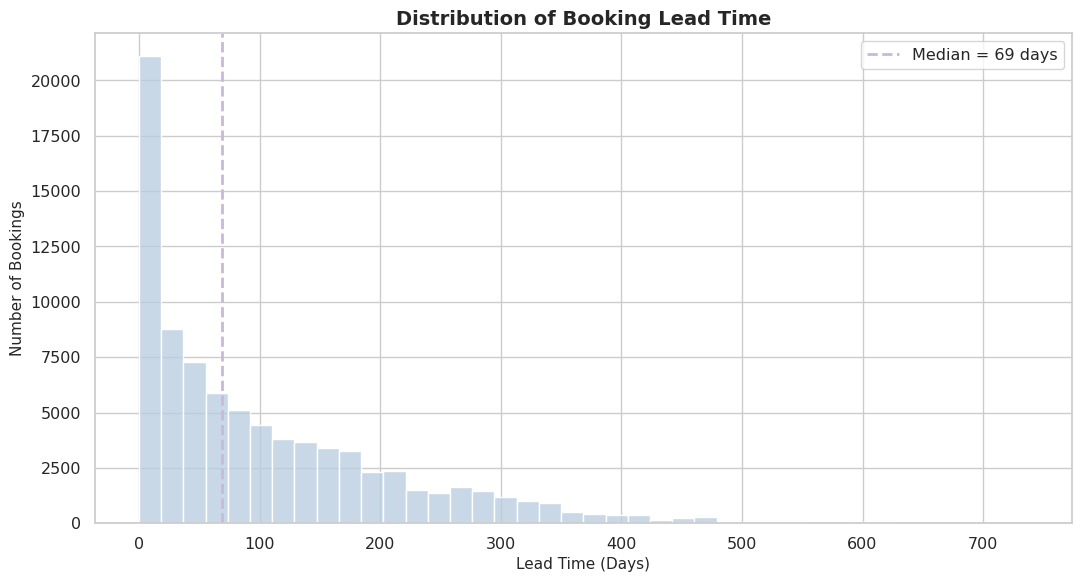

In [56]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x='lead_time',
    bins=40,
    color='#B8CCE0',
    edgecolor='white')

plt.axvline(
    df['lead_time'].median(),
    linestyle='--',
    linewidth=2,
    color='#C9B8D9',
    label=f"Median = {df['lead_time'].median():.0f} days")

plt.title('Distribution of Booking Lead Time')

plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Bookings')

plt.legend()
plt.tight_layout()
plt.show()

Distribusi lead time menunjukkan bahwa booking tidak tersebar secara merata. Median berada pada sekitar 69 hari, sedangkan maximum mencapai 737 hari

Ini memberi indikasi bahwa terdapat kelompok booking yang dibuat jauh sebelum tanggal kedatangan

Namun, kita belum boleh menyimpulkan bahwa lead time panjang menyebabkan cancellation

Untuk membuktikannya, kita perlu membandingkan lead time dengan is_canceled

##**Cancellation Distribution**

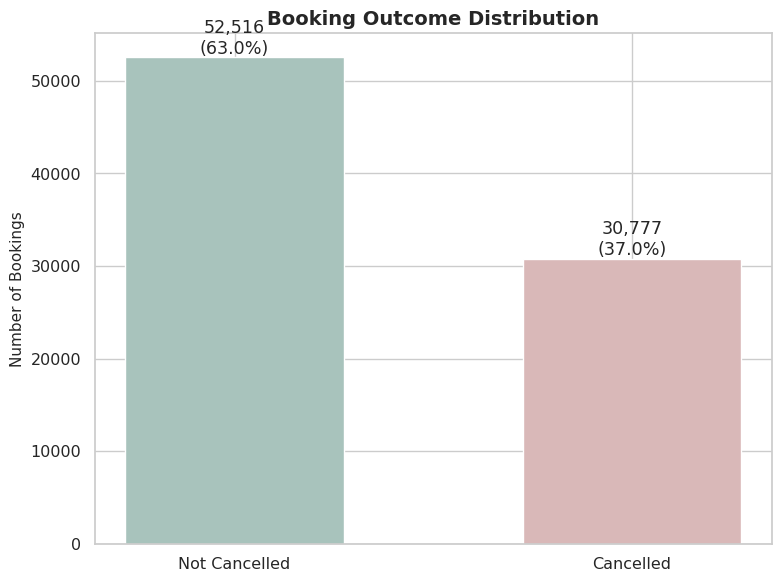

In [57]:
cancellation_summary = (
    df['is_canceled']
    .value_counts()
    .sort_index())

labels = [
    'Not Cancelled',
    'Cancelled']

values = [
    cancellation_summary.get(0, 0),
    cancellation_summary.get(1, 0)]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    labels,
    values,
    color=[
        '#A8C3BC',
        '#D9B8B8'],width=0.55)

plt.title('Booking Outcome Distribution')
plt.ylabel('Number of Bookings')

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:,}\n({value/len(df)*100:.1f}%)',
        ha='center',
        va='bottom')

plt.tight_layout()
plt.show()

Dari 83.293 booking:
*   52.516 booking (63,05%) tidak cancelled
*   30.777 booking (36,95%) cancelled

Yang artinya hampir 37% booking akan berakhir dengan canccelation, yang memperkuat Business Problem yang ada bahwa cancellation bukan fenomena kecil yang bisa diabaikan



##**Cancellation Rate By Lead Time**

In [58]:
lead_analysis = (
    df.groupby('lead_time_category')
    .agg(
        bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean'),
        revenue_exposure=('estimated_revenue',
                          lambda x: x[df.loc[x.index, 'is_canceled'] == 1].sum())
    ).reset_index())

lead_analysis['cancellation_rate'] *= 100

lead_order = [
    'Last Minute',
    'Short Lead Time',
    'Medium Lead Time',
    'Long Lead Time',
    'Very Long Lead Time']

lead_analysis['lead_time_category'] = pd.Categorical(
    lead_analysis['lead_time_category'],
    categories=lead_order,
    ordered=True)

lead_analysis = lead_analysis.sort_values('lead_time_category')

display(lead_analysis.round(2))

,lead_time_category,bookings,cancellation_rate,revenue_exposure
0,Last Minute,13739,9.740,312863.780
3,Short Lead Time,13205,27.550,1409364.300
2,Medium Lead Time,20701,37.610,3050827.140
1,Long Lead Time,18498,44.720,3563962.470
4,Very Long Lead Time,17150,56.820,3319951.510


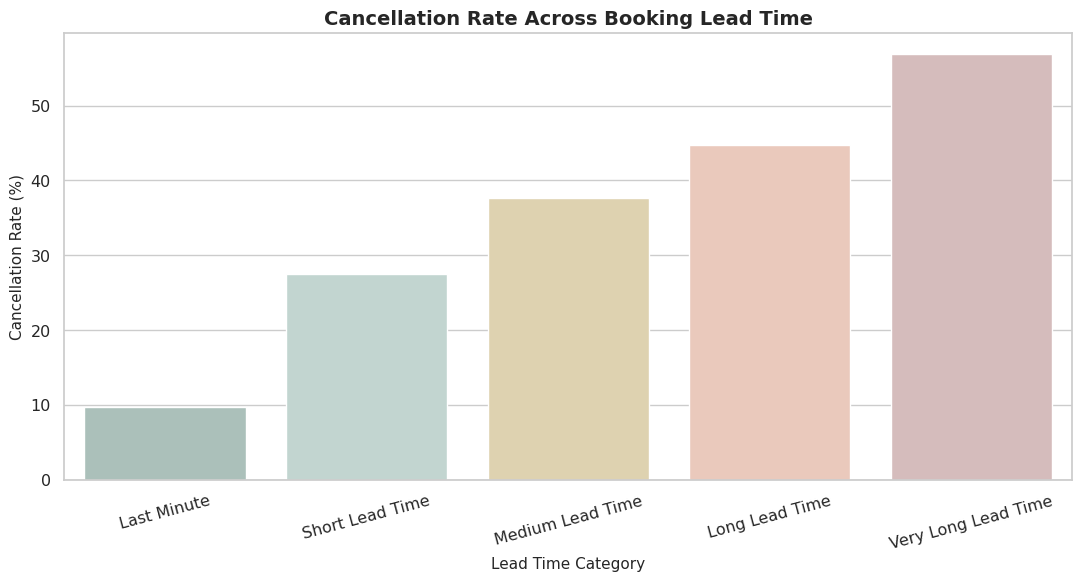

In [59]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=lead_analysis,
    x='lead_time_category',
    y='cancellation_rate',
    hue='lead_time_category',
    palette=[
        '#A8C3BC',
        '#BFD8D2',
        '#E6D5A8',
        '#F2C6B4',
        '#D9B8B8'],
    legend=False)

plt.title(
    'Cancellation Rate Across Booking Lead Time')

plt.xlabel('Lead Time Category')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Ada pola monoton naik: semakin panjang lead time, semakin tinggi cancellation rate

Booking dengan Very Long Lead Time memiliki cancellation rate 56,82%, jauh lebih tinggi dibanding Last Minute sebesar 9,74%

##**Boxplot Lead Time VS Cancellation**

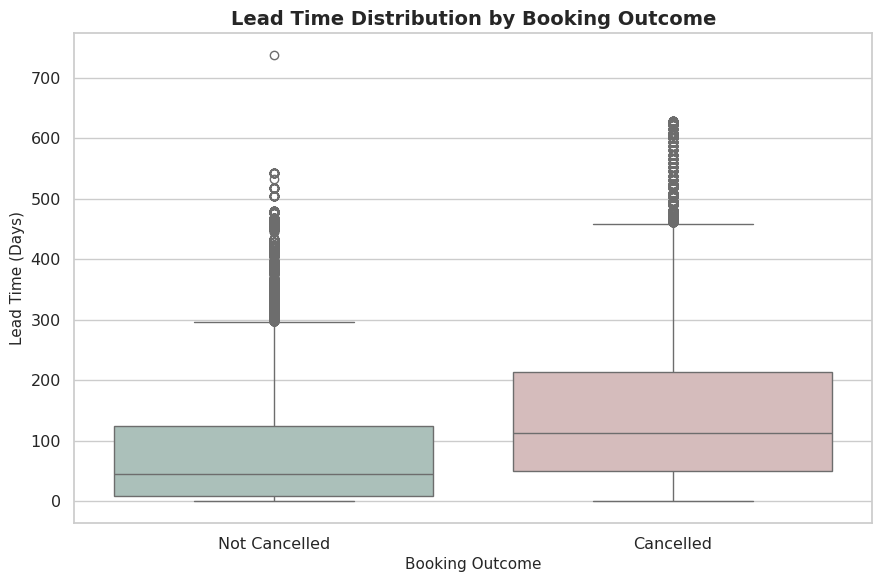

In [60]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='lead_time',
    hue='is_canceled',
    palette=[
        '#A8C3BC',
        '#D9B8B8'
    ],
    legend=False
)

plt.title(
    'Lead Time Distribution by Booking Outcome'
)

plt.xlabel('Booking Outcome')
plt.ylabel('Lead Time (Days)')

plt.xticks(
    [0, 1],
    ['Not Cancelled', 'Cancelled']
)

plt.tight_layout()
plt.show()

Hasil menunjukan bahwa distribusi cancelled bergeser lebih tinggi, ini semakin memperkuat indikasi bahwa booking yang cancelled cenderung memiliki lead time lebih panjang

##**Cancellation VS Previous Cancellation History**

In [61]:
history_analysis = (
    df.groupby('customer_history_category')
    .agg(
        bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

history_analysis['cancellation_rate'] *= 100

display(
    history_analysis.sort_values(
        'cancellation_rate',
        ascending=False
    ).round(2)
)

,customer_history_category,bookings,cancellation_rate
0,High Cancellation History,4011,98.450
1,New Customer,76826,34.770
3,Some Cancellation History,386,16.580
2,Reliable Returning Customer,2070,2.370


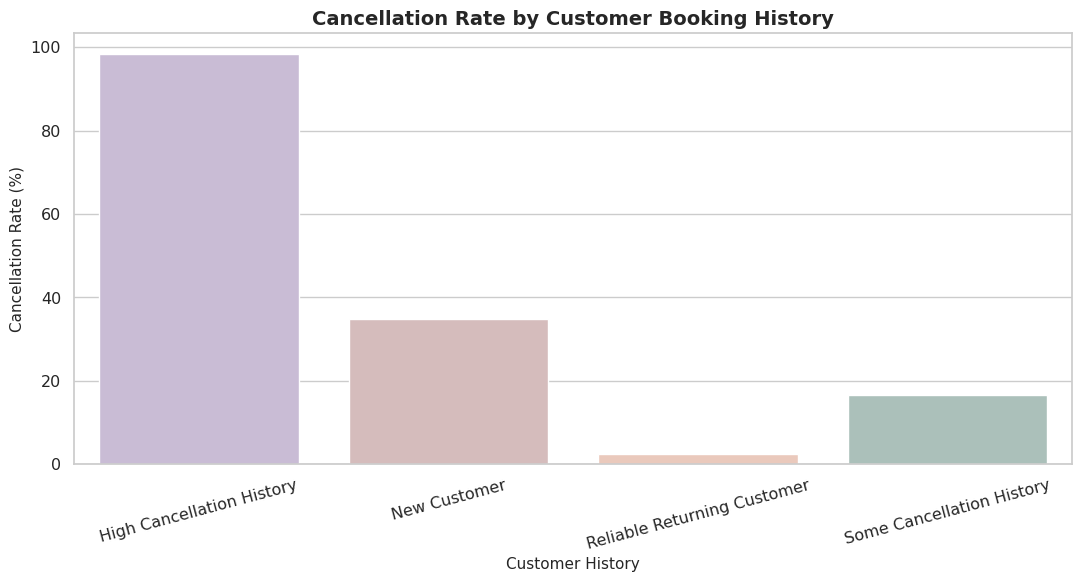

In [62]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=history_analysis,
    x='customer_history_category',
    y='cancellation_rate',
    hue='customer_history_category',
    palette=[
        '#C9B8D9',
        '#D9B8B8',
        '#F2C6B4',
        '#A8C3BC'
    ],
    legend=False
)

plt.title(
    'Cancellation Rate by Customer Booking History'
)

plt.xlabel('Customer History')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

##**Coorelation Heatmap**

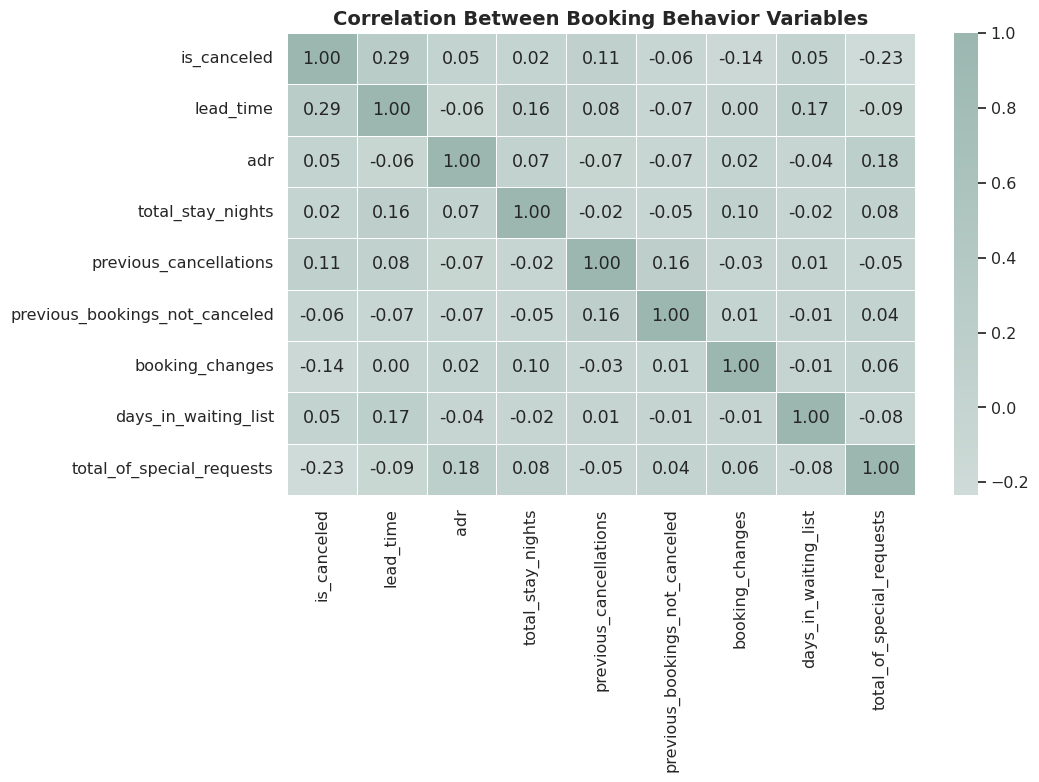

In [63]:
correlation_features = [
    'is_canceled',
    'lead_time',
    'adr',
    'total_stay_nights',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'total_of_special_requests'
]

corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap=sns.light_palette(
        '#9BB7B0',
        as_cmap=True
    ),
    linewidths=0.5,
    center=0
)

plt.title(
    'Correlation Between Booking Behavior Variables'
)

plt.tight_layout()
plt.show()

##**Spesial Request VS Cancellation**

In [64]:
request_analysis = (
    df.groupby('special_request_category')
    .agg(
        bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

request_analysis['cancellation_rate'] *= 100

display(
    request_analysis.round(2)
)

,special_request_category,bookings,cancellation_rate
0,High,11058,21.190
1,Low,23200,21.880
2,No Request,49035,47.630


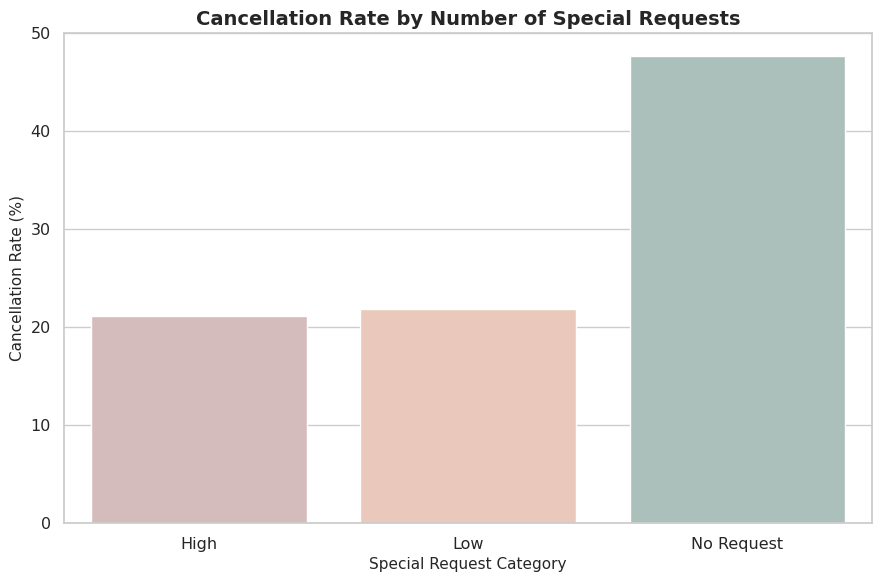

In [65]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=request_analysis,
    x='special_request_category',
    y='cancellation_rate',
    hue='special_request_category',
    palette=[
        '#D9B8B8',
        '#F2C6B4',
        '#A8C3BC'
    ],
    legend=False
)

plt.title(
    'Cancellation Rate by Number of Special Requests'
)

plt.xlabel('Special Request Category')
plt.ylabel('Cancellation Rate (%)')

plt.tight_layout()
plt.show()

##**Market Segment Analysis**

In [66]:
market_analysis = (
    df.groupby('market_segment')
    .agg(
        bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean'),
        total_estimated_revenue=('estimated_revenue', 'sum'),
        revenue_exposure=(
            'estimated_revenue',
            lambda x: x[df.loc[x.index, 'is_canceled'] == 1].sum()
        )
    )
    .reset_index()
)

market_analysis['cancellation_rate'] *= 100

display(
    market_analysis
    .sort_values('bookings', ascending=False)
    .round(2)
)

,market_segment,bookings,cancellation_rate,total_estimated_revenue,revenue_exposure
6,Online TA,39445,36.640,16697284.750,7121217.990
5,Offline TA/TO,16922,34.300,5691498.170,1731548.990
4,Groups,13791,60.660,3266979.160,1948497.450
3,Direct,8742,15.400,3571245.740,706583.880
2,Corporate,3706,19.020,546803.660,137725.890
1,Complementary,524,12.210,3307.050,154.000
0,Aviation,162,24.690,61363.360,11205.000
7,Undefined,1,100.000,36.000,36.000


###**Market Segement - Booking Volume**

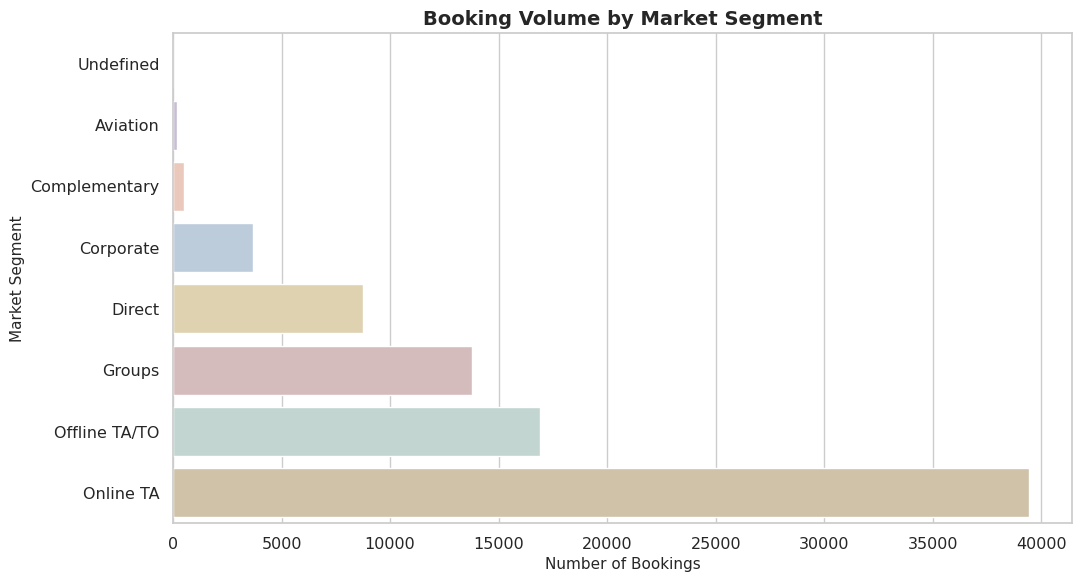

In [67]:
plt.figure(figsize=(11, 6))

market_sorted = market_analysis.sort_values(
    'bookings',
    ascending=True
)

sns.barplot(
    data=market_sorted,
    y='market_segment',
    x='bookings',
    hue='market_segment',
    palette=soft_palette,
    legend=False
)

plt.title(
    'Booking Volume by Market Segment'
)

plt.xlabel('Number of Bookings')
plt.ylabel('Market Segment')

plt.tight_layout()
plt.show()

###**Market Segement - Cancellation Rate**

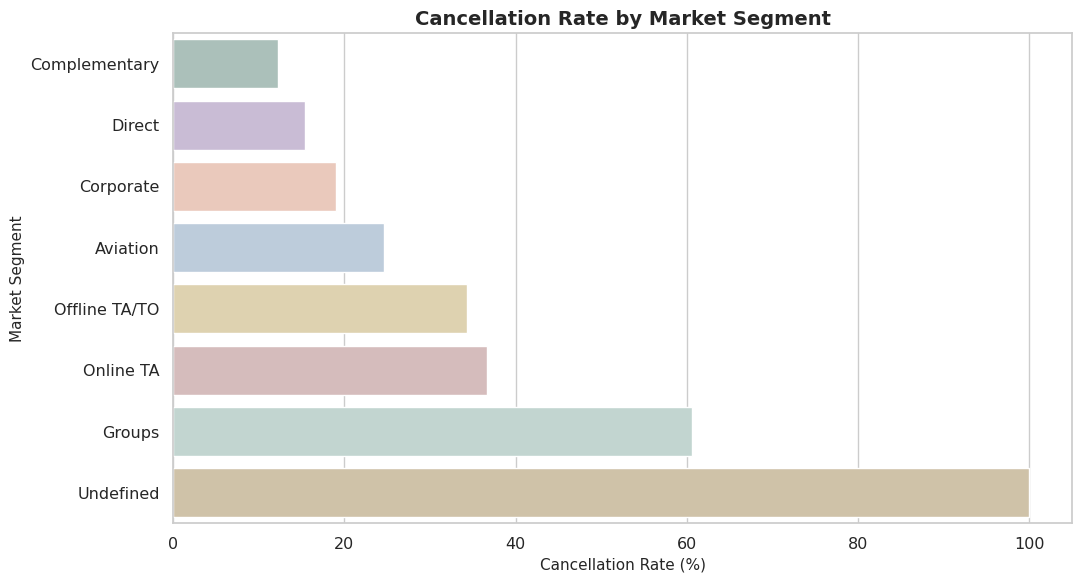

In [68]:
plt.figure(figsize=(11, 6))

market_sorted = market_analysis.sort_values(
    'cancellation_rate',
    ascending=True
)

sns.barplot(
    data=market_sorted,
    y='market_segment',
    x='cancellation_rate',
    hue='market_segment',
    palette=soft_palette,
    legend=False
)

plt.title(
    'Cancellation Rate by Market Segment'
)

plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Market Segment')

plt.tight_layout()
plt.show()

##**Distribution Channel**

In [69]:
channel_analysis = (
    df.groupby('distribution_channel')
    .agg(
        bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean'),
        revenue=('estimated_revenue', 'sum')
    )
    .reset_index()
)

channel_analysis['cancellation_rate'] *= 100

display(
    channel_analysis
    .sort_values('bookings', ascending=False)
    .round(2)
)

,distribution_channel,bookings,cancellation_rate,revenue
3,TA/TO,68368,40.860,25194024.070
1,Direct,10156,17.570,3835413.420
0,Corporate,4632,22.280,777333.870
2,GDS,133,19.550,30587.530
4,Undefined,4,75.000,1159.000


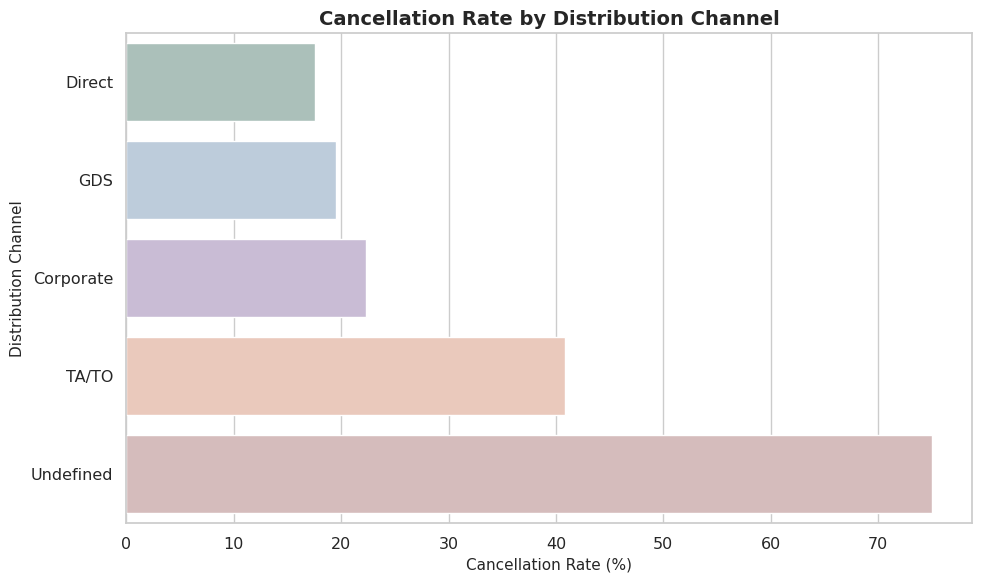

In [70]:
plt.figure(figsize=(10, 6))

channel_sorted = channel_analysis.sort_values(
    'cancellation_rate',
    ascending=True
)

sns.barplot(
    data=channel_sorted,
    y='distribution_channel',
    x='cancellation_rate',
    hue='distribution_channel',
    palette=[
        '#A8C3BC',
        '#B8CCE0',
        '#C9B8D9',
        '#F2C6B4',
        '#D9B8B8'
    ],
    legend=False
)

plt.title(
    'Cancellation Rate by Distribution Channel'
)

plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Distribution Channel')

plt.tight_layout()
plt.show()

##**Deposit Type — Interesting Finding**

In [71]:
deposit_analysis = (
    df.groupby('deposit_type')
    .agg(
        bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean'),
        revenue_exposure=(
            'estimated_revenue',
            lambda x: x[df.loc[x.index, 'is_canceled'] == 1].sum()
        )
    )
    .reset_index()
)

deposit_analysis['cancellation_rate'] *= 100

display(
    deposit_analysis.round(2)
)

,deposit_type,bookings,cancellation_rate,revenue_exposure
0,No Deposit,72979,28.250,9119473.870
1,Non Refund,10204,99.320,2522825.550
2,Refundable,110,21.820,14669.780


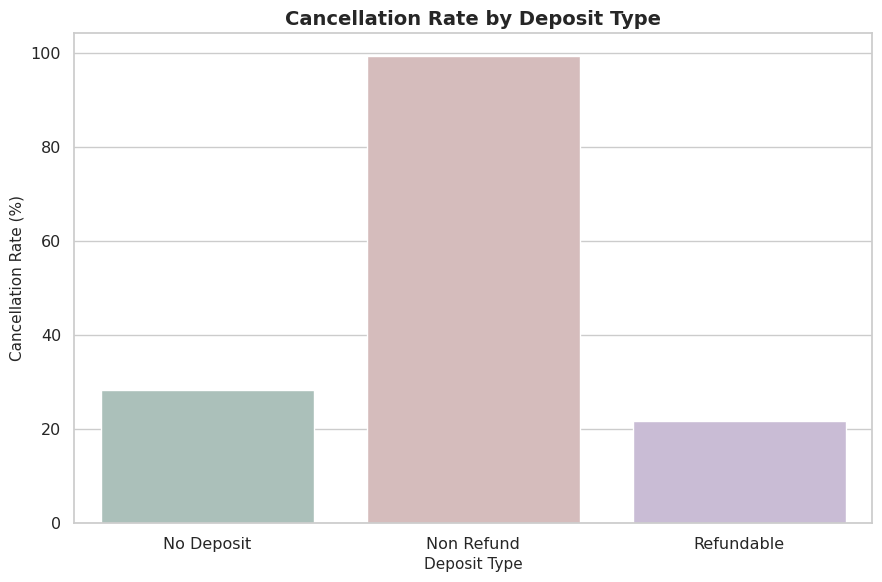

In [72]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=deposit_analysis,
    x='deposit_type',
    y='cancellation_rate',
    hue='deposit_type',
    palette=[
        '#A8C3BC',
        '#D9B8B8',
        '#C9B8D9'
    ],
    legend=False
)

plt.title(
    'Cancellation Rate by Deposit Type'
)

plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')

plt.tight_layout()
plt.show()

##**Revenue Exporsure**

In [73]:
revenue_summary = (
    df.groupby('revenue_status')
    .agg(
        bookings=('is_canceled', 'size'),
        estimated_revenue=('estimated_revenue', 'sum')
    )
    .reset_index()
)

display(
    revenue_summary.round(2)
)

,revenue_status,bookings,estimated_revenue
0,At Risk,30777,11656969.200
1,Realized,52516,18181548.690


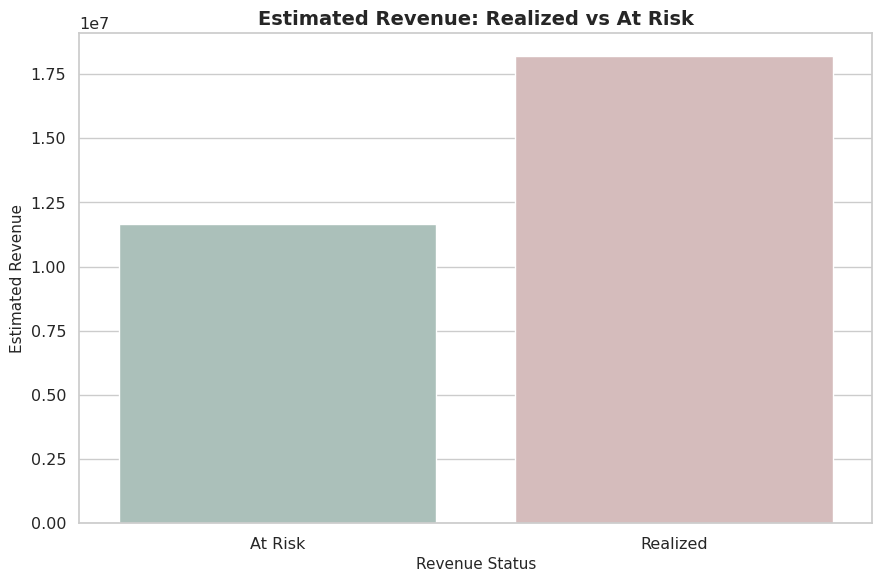

In [74]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=revenue_summary,
    x='revenue_status',
    y='estimated_revenue',
    hue='revenue_status',
    palette=[
        '#A8C3BC',
        '#D9B8B8'
    ],
    legend=False
)

plt.title(
    'Estimated Revenue: Realized vs At Risk'
)

plt.xlabel('Revenue Status')
plt.ylabel('Estimated Revenue')

plt.tight_layout()
plt.show()

##**Revenue Exporsure By Market Segment**

In [75]:
exposure_by_market = (
    df[df['is_canceled'] == 1]
    .groupby('market_segment')
    .agg(
        cancelled_bookings=('is_canceled', 'size'),
        revenue_exposure=('estimated_revenue', 'sum')
    )
    .reset_index()
    .sort_values(
        'revenue_exposure',
        ascending=False
    )
)

display(
    exposure_by_market.round(2)
)

,market_segment,cancelled_bookings,revenue_exposure
6,Online TA,14452,7121217.990
4,Groups,8365,1948497.450
5,Offline TA/TO,5804,1731548.990
3,Direct,1346,706583.880
2,Corporate,705,137725.890
0,Aviation,40,11205.000
1,Complementary,64,154.000
7,Undefined,1,36.000


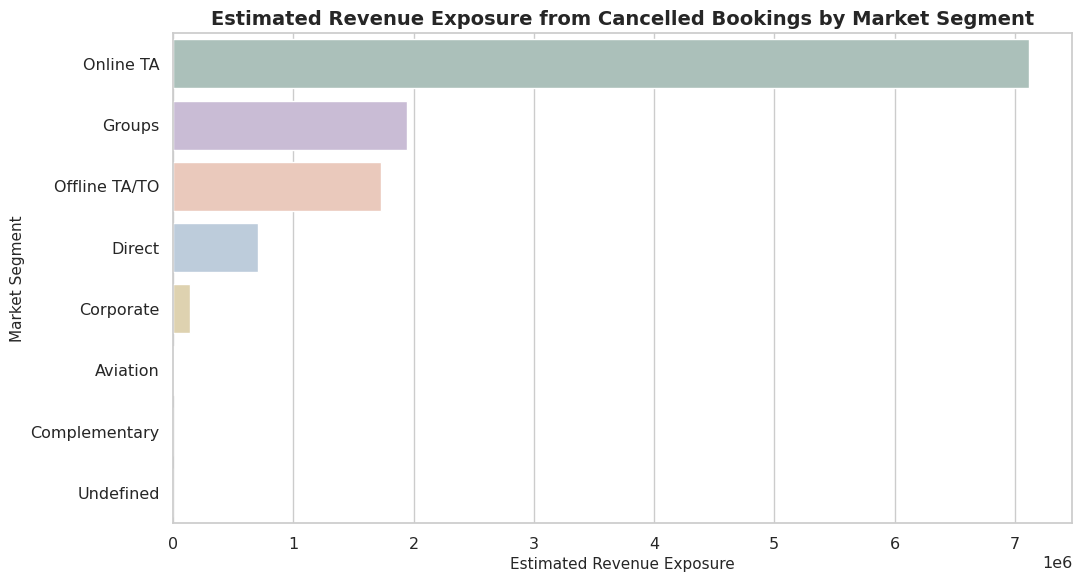

In [76]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=exposure_by_market,
    y='market_segment',
    x='revenue_exposure',
    hue='market_segment',
    palette=soft_palette,
    legend=False
)

plt.title(
    'Estimated Revenue Exposure from Cancelled Bookings by Market Segment'
)

plt.xlabel('Estimated Revenue Exposure')
plt.ylabel('Market Segment')

plt.tight_layout()
plt.show()

##**Scatter - Lead Time VS ADR**

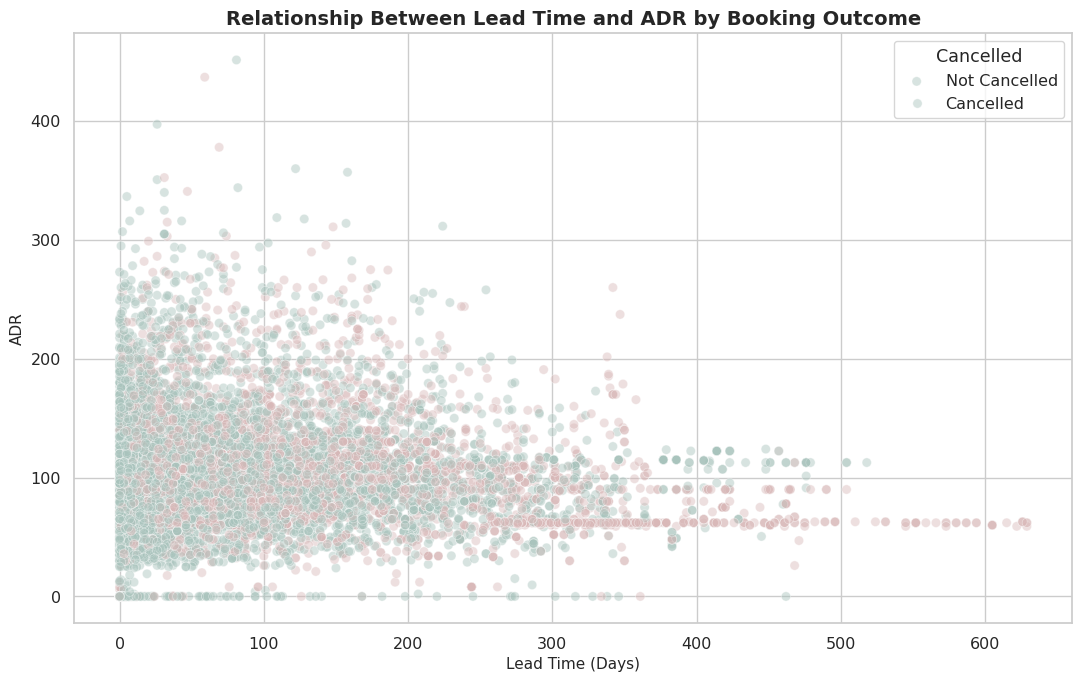

In [77]:
sample_df = df.sample(
    min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=sample_df,
    x='lead_time',
    y='adr',
    hue='is_canceled',
    palette={
        0: '#A8C3BC',
        1: '#D9B8B8'
    },
    alpha=0.45,
    s=45
)

plt.title(
    'Relationship Between Lead Time and ADR by Booking Outcome'
)

plt.xlabel('Lead Time (Days)')
plt.ylabel('ADR')

plt.legend(
    title='Cancelled',
    labels=['Not Cancelled', 'Cancelled']
)

plt.tight_layout()
plt.show()

##Customer Value VS Cancellation

In [78]:
df['revenue_percentile'] = (
    df['estimated_revenue']
    .rank(pct=True)
)

df['revenue_value_category'] = pd.cut(
    df['revenue_percentile'],
    bins=[0, 0.5, 0.8, 0.95, 1],
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Very High Value'
    ],
    include_lowest=True
)

In [79]:
value_analysis = (
    df.groupby('revenue_value_category',
               observed=True)
    .agg(
        bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean'),
        revenue_exposure=(
            'estimated_revenue',
            lambda x: x[df.loc[x.index, 'is_canceled'] == 1].sum()
        )
    )
    .reset_index()
)

value_analysis['cancellation_rate'] *= 100

display(
    value_analysis.round(2)
)

,revenue_value_category,bookings,cancellation_rate,revenue_exposure
0,Low Value,41657,35.310,2353289.590
1,Medium Value,24956,38.450,3484834.730
2,High Value,12514,37.470,3208183.820
3,Very High Value,4166,42.750,2610661.060


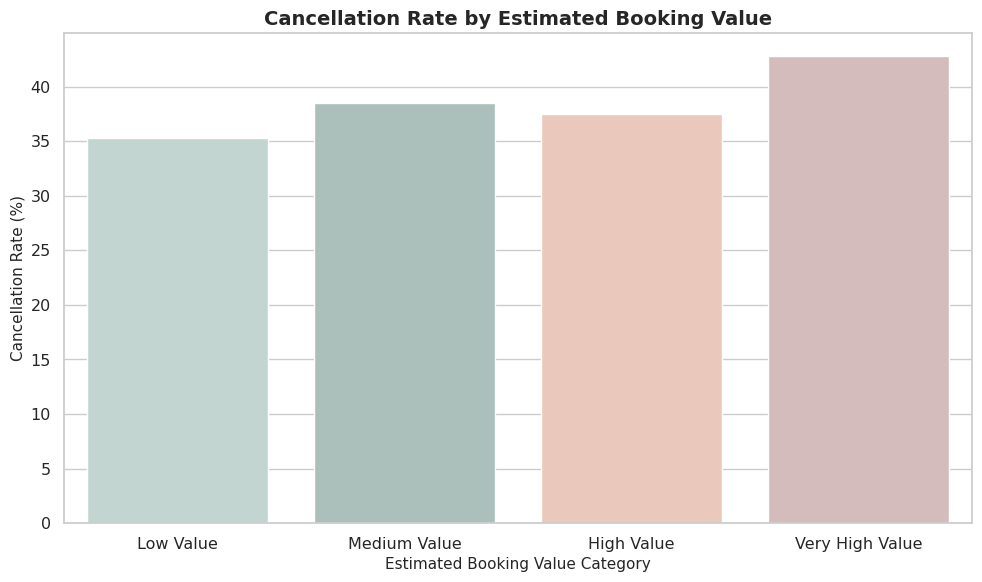

In [80]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=value_analysis,
    x='revenue_value_category',
    y='cancellation_rate',
    hue='revenue_value_category',
    palette=[
        '#BFD8D2',
        '#A8C3BC',
        '#F2C6B4',
        '#D9B8B8'
    ],
    legend=False
)

plt.title(
    'Cancellation Rate by Estimated Booking Value'
)

plt.xlabel('Estimated Booking Value Category')
plt.ylabel('Cancellation Rate (%)')

plt.tight_layout()
plt.show()

#**Statical Analysis & Business Insight**

Tahap ini bertujuan untuk mengubah pola yang ditemukan pada EDA menjadi evidence yang lebih kuat secara statistik.

EDA sebelumnya menunjukkan adanya perbedaan cancellation berdasarkan lead_time, customer history, market segment, dan distribution channel. Namun, perbedaan secara visual belum cukup untuk menyatakan bahwa pola tersebut benar-benar signifikan secara statistik.

Karena itu, statistical analysis difokuskan hanya pada hubungan yang paling relevan dengan business problem:

1. Lead Time → Cancellation
2. Market Segment / Distribution Channel → Cancellation
3. Customer Behavior → Cancellation

Kemudian hasil statistik tersebut akan digunakan untuk menentukan revenue exposure dan high-risk/high-value segment

##**Hypotesis Framework**

Test 1 — Lead Time vs Cancellation

H₀: Distribusi lead time antara booking cancelled dan non-cancelled tidak berbeda secara signifikan

H₁: Distribusi lead time antara booking cancelled dan non-cancelled berbeda secara signifikan

Test 2 — Market Segment vs Cancellation

H₀: Market segment dan cancellation status tidak memiliki hubungan

H₁: Market segment dan cancellation status memiliki hubungan

Test 3 — Customer History vs Cancellation

H₀: Customer history category dan cancellation status tidak memiliki hubungan

H₁: Customer history category dan cancellation status memiliki hubungan

##**Statistical Significance**

alpha = 0.05

Interpretasi:

1. p-value < 0.05 → reject H₀ → terdapat evidence adanya hubungan/perbedaan yang signifikan
2. p-value >= 0.05 → fail to reject H₀ → belum cukup evidence untuk menyatakan adanya hubungan/perbedaan


##**Test 1 Lead Time VS Cancellation**

In [81]:
from scipy.stats import mannwhitneyu

lead_time_cancelled = df.loc[
    df['is_canceled'] == 1,
    'lead_time'
]

lead_time_not_cancelled = df.loc[
    df['is_canceled'] == 0,
    'lead_time'
]

u_stat, p_value = mannwhitneyu(
    lead_time_cancelled,
    lead_time_not_cancelled,
    alternative='two-sided'
)

print(f"Mann-Whitney U Statistic: {u_stat:,.2f}")
print(f"P-value: {p_value:.10f}")

Mann-Whitney U Statistic: 1,113,014,492.50
P-value: 0.0000000000


Reject H₀

Artinya terdapat perbedaan yang signifikan pada distribusi lead time antara booking cancelled dan non-cancelled

###**Menambahkan Median**

In [82]:
median_cancelled = lead_time_cancelled.median()
median_not_cancelled = lead_time_not_cancelled.median()

print(f"Median Lead Time - Cancelled: {median_cancelled:.0f} days")
print(f"Median Lead Time - Not Cancelled: {median_not_cancelled:.0f} days")

Median Lead Time - Cancelled: 113 days
Median Lead Time - Not Cancelled: 45 days


Booking yang mengalami cancellation cenderung memiliki lead time yang lebih panjang dibandingkan booking yang tidak cancelled

###**Effect Size - Cliff'S Delta**

In [83]:
def cliffs_delta(x, y):

    x = np.asarray(x)
    y = np.asarray(y)

    greater = 0
    less = 0

    for value_x in x:
        greater += np.sum(value_x > y)
        less += np.sum(value_x < y)

    delta = (greater - less) / (len(x) * len(y))

    return delta


delta = cliffs_delta(
    lead_time_cancelled.values,
    lead_time_not_cancelled.values
)


print(f"Cliff's Delta: {delta:.4f}")

Cliff's Delta: 0.3773


Jika Hasil Nya :

1. (<) 0.147	Negligible
2. 0.147–0.33	Small
3. 0.33–0.474	Medium
4. (>) 0.474	Large

Maka Perbedaan Tersebut signifikan secara statistik dengan efek praktis yang kecil

##**Test 2 - Makrket Segment VS Cancellation**

In [84]:
market_crosstab = pd.crosstab(
    df['market_segment'],
    df['is_canceled']
)

market_crosstab.columns = [
    'Not Cancelled',
    'Cancelled'
]

display(market_crosstab)

,Not Cancelled,Cancelled
market_segment,,
Aviation,122,40
Complementary,460,64
Corporate,3001,705
Direct,7396,1346
Groups,5426,8365
Offline TA/TO,11118,5804
Online TA,24993,14452
Undefined,0,1


In [85]:
market_percentage = pd.crosstab(
    df['market_segment'],
    df['is_canceled'],
    normalize='index'
) * 100

market_percentage.columns = [
    'Not Cancelled (%)',
    'Cancelled (%)'
]

display(
    market_percentage.round(2)
)

,Not Cancelled (%),Cancelled (%)
market_segment,,
Aviation,75.310,24.690
Complementary,87.790,12.210
Corporate,80.980,19.020
Direct,84.600,15.400
Groups,39.340,60.660
Offline TA/TO,65.700,34.300
Online TA,63.360,36.640
Undefined,0.000,100.000


###**Chi - Square Test**

In [86]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    market_crosstab
)

print(f"Chi-Square Statistic: {chi2:,.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.10f}")

Chi-Square Statistic: 5,783.38
Degrees of Freedom: 7
P-value: 0.0000000000


Reject H₀.

Karena terdapat statistically significant association antara market segment dan cancellation status

###Effect Size - Cramer's V

In [87]:
n = market_crosstab.values.sum()

min_dimension = min(
    market_crosstab.shape
) - 1

cramers_v = np.sqrt(
    chi2 / (n * min_dimension)
)

print(f"Cramer's V: {cramers_v:.4f}")

Cramer's V: 0.2635


Interpretasi :

1. sekitar 0 → hubungan sangat lemah
2. semakin mendekati 1 → hubungan semakin kuat

Uji Chi-Square menunjukkan adanya hubungan yang signifikan secara statistik antara segmen pasar dan status pembatalan. Hal ini mengonfirmasi bahwa perilaku pembatalan tidak terdistribusi secara merata di berbagai segmen pasar. Analisis deskriptif lebih lanjut memperlihatkan perbedaan yang nyata dalam tingkat pembatalan antar-segmen, yang mengindikasikan bahwa kinerja saluran distribusi sebaiknya tidak dievaluasi semata-mata berdasarkan volume pemesanan

Oleh karena itu, perusahaan sebaiknya mengevaluasi segmen pasar berdasarkan kombinasi antara volume pemesanan, tingkat pembatalan, dan estimasi eksposur pendapatan, alih-alih hanya menggunakan volume pemesanan sebagai satu-satunya tolok ukur kinerja.

##**Customer History VS Cancellation**

In [88]:
history_crosstab = pd.crosstab(
    df['customer_history_category'],
    df['is_canceled']
)

history_crosstab.columns = [
    'Not Cancelled',
    'Cancelled'
]

display(history_crosstab)

,Not Cancelled,Cancelled
customer_history_category,,
High Cancellation History,62,3949
New Customer,50111,26715
Reliable Returning Customer,2021,49
Some Cancellation History,322,64


In [89]:
history_percentage = pd.crosstab(
    df['customer_history_category'],
    df['is_canceled'],
    normalize='index'
) * 100

history_percentage.columns = [
    'Not Cancelled (%)',
    'Cancelled (%)'
]

display(
    history_percentage.round(2)
)

,Not Cancelled (%),Cancelled (%)
customer_history_category,,
High Cancellation History,1.550,98.450
New Customer,65.230,34.770
Reliable Returning Customer,97.630,2.370
Some Cancellation History,83.420,16.580


###**Chi-Square Customer History**

In [90]:
chi2_history, p_history, dof_history, expected_history = (
    chi2_contingency(history_crosstab)
)

print(f"Chi-Square Statistic: {chi2_history:,.2f}")
print(f"Degrees of Freedom: {dof_history}")
print(f"P-value: {p_history:.10f}")

Chi-Square Statistic: 7,800.35
Degrees of Freedom: 3
P-value: 0.0000000000


##**Cramer'S V Customer History**

In [91]:
n_history = history_crosstab.values.sum()

min_dimension_history = (
    min(history_crosstab.shape) - 1
)

cramers_v_history = np.sqrt(
    chi2_history /
    (n_history * min_dimension_history)
)

print(
    f"Cramer's V: {cramers_v_history:.4f}"
)

Cramer's V: 0.3060


In [92]:
customer_cancellation_rate = (
    df.groupby('customer_history_category')
    ['is_canceled']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(
    customer_cancellation_rate.round(2)
)

,is_canceled
customer_history_category,
High Cancellation History,98.450
New Customer,34.770
Some Cancellation History,16.580
Reliable Returning Customer,2.370


#**Deep Dive High Value X High Cancellation**

In [93]:
high_value_cancelled = df[
    (
        df['revenue_value_category'].isin(
            ['High Value', 'Very High Value']
        )
    )
    &
    (df['is_canceled'] == 1)
]

print(
    "High-value cancelled bookings:",
    len(high_value_cancelled)
)

print(
    "Estimated revenue exposure:",
    high_value_cancelled['estimated_revenue'].sum()
)

High-value cancelled bookings: 6470
Estimated revenue exposure: 5818844.88


###**High-Risk + High-Value Segment**

In [94]:
high_risk_high_value = df[
    (
        df['is_canceled'] == 1
    )
    &
    (
        df['lead_time'] >
        df['lead_time'].median()
    )
    &
    (
        df['estimated_revenue'] >=
        df['estimated_revenue'].quantile(0.80)
    )
]

risk_value_summary = {
    'Bookings': len(high_risk_high_value),
    'Estimated Revenue Exposure':
        high_risk_high_value['estimated_revenue'].sum(),
    'Average Lead Time':
        high_risk_high_value['lead_time'].mean(),
    'Average ADR':
        high_risk_high_value['adr'].mean()
}

display(
    pd.Series(risk_value_summary)
)

,0
Bookings,4393.000
Estimated Revenue Exposure,3938708.530
Average Lead Time,168.890
Average ADR,145.527


###**Revenue Exposure By Risk Profile**

In [95]:
df['risk_profile'] = np.select(
    [
        (
            (df['lead_time'] > df['lead_time'].median()) &
            (df['historical_cancellation_rate'] > 0)
        ),

        (
            df['lead_time'] > df['lead_time'].median()
        ),

        (
            df['historical_cancellation_rate'] > 0
        )
    ],
    [
        'High Behavioral Risk',
        'Long Lead Time',
        'Cancellation History'
    ],
    default='Lower Behavioral Risk'
)

In [96]:
df['risk_profile'] = np.select(
    [
        (
            (df['lead_time'] > df['lead_time'].median()) &
            (df['historical_cancellation_rate'] > 0)
        ),

        (
            df['lead_time'] > df['lead_time'].median()
        ),

        (
            df['historical_cancellation_rate'] > 0
        )
    ],
    [
        'High Behavioral Risk',
        'Long Lead Time',
        'Cancellation History'
    ],
    default='Lower Behavioral Risk'
)

Risiko pembatalan tidak tersebar secara merata di seluruh pemesanan. Jarak waktu pemesanan (*lead time*) dan riwayat perilaku pelanggan tampaknya merupakan sinyal perilaku yang penting, sementara tingkat pembatalan juga bervariasi secara signifikan antar-segmen pasar. Oleh karena itu, mengevaluasi kinerja pemesanan hanya berdasarkan volume pemesanan dapat menyembunyikan risiko kerugian pendapatan yang substansial. Langkah selanjutnya adalah mengidentifikasi kombinasi perilaku pelanggan, karakteristik pemesanan, saluran, dan nilai pemesanan yang membentuk segmen-segmen paling strategis

#**Customer Booking Segmentation**

##**Check Dataset**

In [97]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,has_comapny,has_agent,total_guests,total_stay_nights,stay_category,estimated_revenue,revenue_status,total_previous_bookings,historical_cancellation_rate,customer_history_category,lead_time_category,has_booking_changes,booking_change_category,has_special_requests,special_request_category,room_type_change,high_lead_time_flag,previous_cancel_flag,long_waiting_flag,reservation_year,reservation_month,reservation_day,reservation_dayofweek,reservation_month_name,arrival_date,arrival_year,arrival_month_num,arrival_month_name,arrival_dayofweek,is_arrival_weekend,revenue_percentile,revenue_value_category,risk_profile
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,0,0,BB,ITA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,314.000,0.000,0,Transient,38.400,0,0,Check-Out,2019-01-14,1,0,1,2,4,Medium Stay,153.600,Realized,0,0.000,New Customer,Short Lead Time,0,No Changes,0,No Request,0,0,0,0,2019,1,14,0,January,2019-01-10,2019,1,January,3,0,0.264,Low Value,Lower Behavioral Risk
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,1.000,0.000,0,Transient,62.800,0,0,Canceled,2017-10-21,2,0,1,2,2,Short Stay,125.600,At Risk,0,0.000,New Customer,Very Long Lead Time,0,No Changes,0,No Request,0,1,0,0,2017,10,21,5,October,2018-12-15,2018,12,December,5,1,0.209,Low Value,Long Lead Time
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,12.000,0.000,0,Transient,110.000,0,0,Canceled,2018-11-25,3,0,1,2,3,Medium Stay,330.000,At Risk,0,0.000,New Customer,Long Lead Time,0,No Changes,0,No Request,0,1,0,0,2018,11,25,6,November,2019-05-19,2019,5,May,6,1,0.611,Medium Value,Long Lead Time
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,0,0,BB,Unknown,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0.000,200.000,0,Transient,45.000,0,0,Check-Out,2018-10-18,4,1,0,1,1,Short Stay,45.000,Realized,0,0.000,New Customer,Last Minute,0,No Changes,0,No Request,0,0,0,0,2018,10,18,3,October,2018-10-17,2018,10,October,2,0,0.038,Low Value,Lower Behavioral Risk
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,16.000,0.000,0,Transient,57.920,0,1,Canceled,2017-08-24,5,0,1,2,5,Medium Stay,289.600,At Risk,0,0.000,New Customer,Medium Lead Time,0,No Changes,1,Low,0,0,0,0,2017,8,24,3,August,2017-09-26,2017,9,September,1,0,0.545,Medium Value,Lower Behavioral Risk


##**Check Ketersediaan Feature**

In [98]:
segmentation_features = [
    'lead_time',
    'adr',
    'estimated_revenue',
    'total_stay_nights',
    'total_guests',
    'total_previous_bookings',
    'previous_cancellations',
    'booking_changes',
    'total_of_special_requests',
    'historical_cancellation_rate',
    'is_repeated_guest'
]

available_features = [
    col for col in segmentation_features
    if col in df.columns
]

missing_features = [
    col for col in segmentation_features
    if col not in df.columns
]

print("Available features:")
print(available_features)

print("\nMissing features:")
print(missing_features)

Available features:
['lead_time', 'adr', 'estimated_revenue', 'total_stay_nights', 'total_guests', 'total_previous_bookings', 'previous_cancellations', 'booking_changes', 'total_of_special_requests', 'historical_cancellation_rate', 'is_repeated_guest']

Missing features:
[]


##**Pemilihan Feature**

In [99]:
clustering_features = [
    'lead_time',
    'adr',
    'estimated_revenue',
    'total_stay_nights',
    'total_guests',
    'total_previous_bookings',
    'previous_cancellations',
    'historical_cancellation_rate'
]

##**Check Distribution**

In [100]:
df[clustering_features].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.914,106.874,0.000,18.000,69.000,160.000,737.000
adr,83293.000,101.724,48.083,0.000,69.530,94.500,126.000,508.000
estimated_revenue,83293.000,358.236,336.264,0.000,147.200,267.000,447.120,7590.000
total_stay_nights,83293.000,3.434,2.579,0.000,2.000,3.000,4.000,69.000
total_guests,83293.000,1.966,0.744,0.000,2.000,2.000,2.000,55.000
total_previous_bookings,83293.000,0.229,1.897,0.000,0.000,0.000,0.000,76.000
previous_cancellations,83293.000,0.087,0.863,0.000,0.000,0.000,0.000,26.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


In [101]:
skewness = (df[clustering_features].skew().sort_values(ascending=False))

print("Skewness:")
print(skewness)

Skewness:
previous_cancellations         24.312
total_previous_bookings        18.688
total_guests                   12.450
historical_cancellation_rate    4.217
total_stay_nights               3.448
estimated_revenue               2.989
lead_time                       1.356
adr                             1.019
dtype: float64


##**Handling extreme Values**

In [102]:
cluster_data = df[clustering_features].copy()

for col in clustering_features:
  lower = cluster_data[col].quantile(0.01)
  upper = cluster_data[col].quantile(0.99)

  cluster_data[col] = cluster_data[col].clip(
      lower=lower,
      upper=upper
  )

  display(cluster_data.describe().T)

,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.331,104.667,0.000,18.000,69.000,160.000,447.000
adr,83293.000,101.724,48.083,0.000,69.530,94.500,126.000,508.000
estimated_revenue,83293.000,358.236,336.264,0.000,147.200,267.000,447.120,7590.000
total_stay_nights,83293.000,3.434,2.579,0.000,2.000,3.000,4.000,69.000
total_guests,83293.000,1.966,0.744,0.000,2.000,2.000,2.000,55.000
total_previous_bookings,83293.000,0.229,1.897,0.000,0.000,0.000,0.000,76.000
previous_cancellations,83293.000,0.087,0.863,0.000,0.000,0.000,0.000,26.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.331,104.667,0.000,18.000,69.000,160.000,447.000
adr,83293.000,101.396,46.824,0.000,69.530,94.500,126.000,252.000
estimated_revenue,83293.000,358.236,336.264,0.000,147.200,267.000,447.120,7590.000
total_stay_nights,83293.000,3.434,2.579,0.000,2.000,3.000,4.000,69.000
total_guests,83293.000,1.966,0.744,0.000,2.000,2.000,2.000,55.000
total_previous_bookings,83293.000,0.229,1.897,0.000,0.000,0.000,0.000,76.000
previous_cancellations,83293.000,0.087,0.863,0.000,0.000,0.000,0.000,26.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.331,104.667,0.000,18.000,69.000,160.000,447.000
adr,83293.000,101.396,46.824,0.000,69.530,94.500,126.000,252.000
estimated_revenue,83293.000,353.577,309.075,0.000,147.200,267.000,447.120,1680.000
total_stay_nights,83293.000,3.434,2.579,0.000,2.000,3.000,4.000,69.000
total_guests,83293.000,1.966,0.744,0.000,2.000,2.000,2.000,55.000
total_previous_bookings,83293.000,0.229,1.897,0.000,0.000,0.000,0.000,76.000
previous_cancellations,83293.000,0.087,0.863,0.000,0.000,0.000,0.000,26.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.331,104.667,0.000,18.000,69.000,160.000,447.000
adr,83293.000,101.396,46.824,0.000,69.530,94.500,126.000,252.000
estimated_revenue,83293.000,353.577,309.075,0.000,147.200,267.000,447.120,1680.000
total_stay_nights,83293.000,3.409,2.344,1.000,2.000,3.000,4.000,14.000
total_guests,83293.000,1.966,0.744,0.000,2.000,2.000,2.000,55.000
total_previous_bookings,83293.000,0.229,1.897,0.000,0.000,0.000,0.000,76.000
previous_cancellations,83293.000,0.087,0.863,0.000,0.000,0.000,0.000,26.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.331,104.667,0.000,18.000,69.000,160.000,447.000
adr,83293.000,101.396,46.824,0.000,69.530,94.500,126.000,252.000
estimated_revenue,83293.000,353.577,309.075,0.000,147.200,267.000,447.120,1680.000
total_stay_nights,83293.000,3.409,2.344,1.000,2.000,3.000,4.000,14.000
total_guests,83293.000,1.963,0.644,1.000,2.000,2.000,2.000,4.000
total_previous_bookings,83293.000,0.229,1.897,0.000,0.000,0.000,0.000,76.000
previous_cancellations,83293.000,0.087,0.863,0.000,0.000,0.000,0.000,26.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.331,104.667,0.000,18.000,69.000,160.000,447.000
adr,83293.000,101.396,46.824,0.000,69.530,94.500,126.000,252.000
estimated_revenue,83293.000,353.577,309.075,0.000,147.200,267.000,447.120,1680.000
total_stay_nights,83293.000,3.409,2.344,1.000,2.000,3.000,4.000,14.000
total_guests,83293.000,1.963,0.644,1.000,2.000,2.000,2.000,4.000
total_previous_bookings,83293.000,0.124,0.525,0.000,0.000,0.000,0.000,4.000
previous_cancellations,83293.000,0.087,0.863,0.000,0.000,0.000,0.000,26.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.331,104.667,0.000,18.000,69.000,160.000,447.000
adr,83293.000,101.396,46.824,0.000,69.530,94.500,126.000,252.000
estimated_revenue,83293.000,353.577,309.075,0.000,147.200,267.000,447.120,1680.000
total_stay_nights,83293.000,3.409,2.344,1.000,2.000,3.000,4.000,14.000
total_guests,83293.000,1.963,0.644,1.000,2.000,2.000,2.000,4.000
total_previous_bookings,83293.000,0.124,0.525,0.000,0.000,0.000,0.000,4.000
previous_cancellations,83293.000,0.053,0.224,0.000,0.000,0.000,0.000,1.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


,count,mean,std,min,25%,50%,75%,max
lead_time,83293.000,103.331,104.667,0.000,18.000,69.000,160.000,447.000
adr,83293.000,101.396,46.824,0.000,69.530,94.500,126.000,252.000
estimated_revenue,83293.000,353.577,309.075,0.000,147.200,267.000,447.120,1680.000
total_stay_nights,83293.000,3.409,2.344,1.000,2.000,3.000,4.000,14.000
total_guests,83293.000,1.963,0.644,1.000,2.000,2.000,2.000,4.000
total_previous_bookings,83293.000,0.124,0.525,0.000,0.000,0.000,0.000,4.000
previous_cancellations,83293.000,0.053,0.224,0.000,0.000,0.000,0.000,1.000
historical_cancellation_rate,83293.000,0.049,0.213,0.000,0.000,0.000,0.000,1.000


##**Standarization**

In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_data)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=cluster_data.index
)

display(X_scaled.head())

,lead_time,adr,estimated_revenue,total_stay_nights,total_guests,total_previous_bookings,previous_cancellations,historical_cancellation_rate
0,-0.911,-1.345,-0.647,0.252,0.058,-0.235,-0.236,-0.228
1,3.283,-0.824,-0.738,-0.601,0.058,-0.235,-0.236,-0.228
2,0.685,0.184,-0.076,-0.175,0.058,-0.235,-0.236,-0.228
3,-0.987,-1.204,-0.998,-1.028,-1.494,-0.235,-0.236,-0.228
4,-0.672,-0.928,-0.207,0.679,0.058,-0.235,-0.236,-0.228


##**Elbow Method**

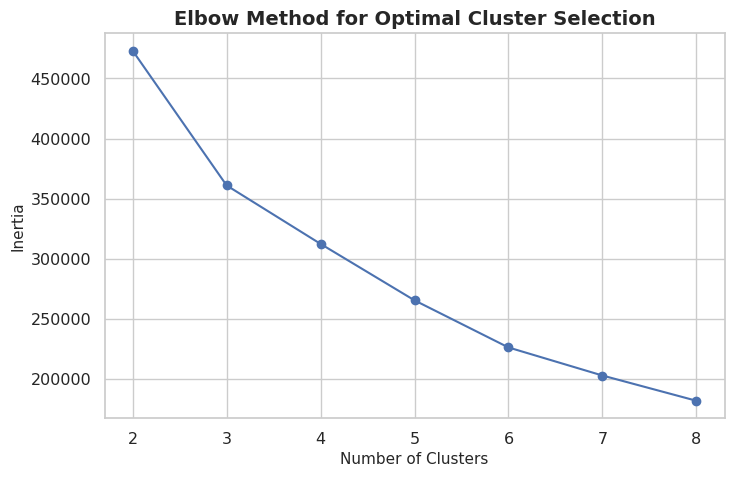

In [104]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 9)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Cluster Selection')

plt.show()

##**Silhouette Score**

In [105]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores[k] = score

silhouette_scores

{2: np.float64(0.6198086177972918),
 3: np.float64(0.34809916313546624),
 4: np.float64(0.37148928386742286),
 5: np.float64(0.27320949554395363),
 6: np.float64(0.2856568574067757),
 7: np.float64(0.29118314771006304),
 8: np.float64(0.29716667379217776)}

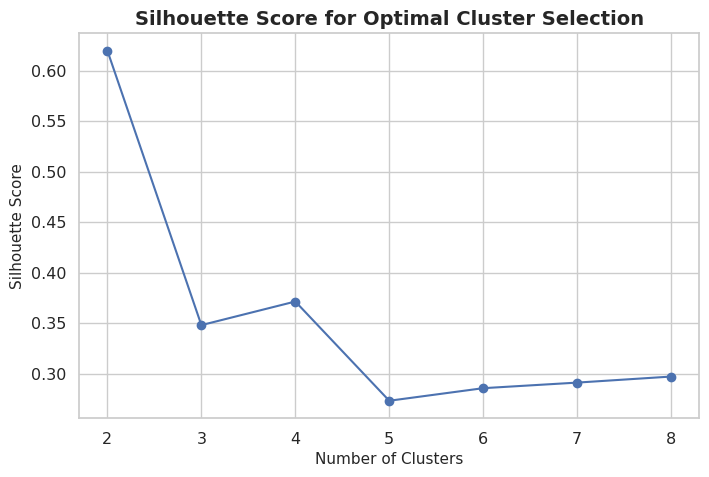

In [106]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal Cluster Selection')

plt.show()

Berdasarkan Metode Elbow, nilai inersia menurun secara signifikan saat jumlah klaster ditingkatkan dari 2 menjadi 3, sementara kurva menjadi semakin landai seiring dengan penambahan jumlah klaster. Namun, Silhouette Score menunjukkan bahwa K=2 menghasilkan kualitas klasterisasi terbaik dengan skor 0,6198, yang jauh lebih tinggi dibandingkan konfigurasi lain yang diuji. Oleh karena itu, K=2 dipilih sebagai jumlah klaster yang optimal karena memberikan pemisahan paling jelas serta mempertahankan kohesi klaster yang kuat tanpa menambah jumlah segmen secara berlebihan.

##**Final K-Means Clustering**

In [108]:
from sklearn.cluster import KMeans

# Optimal number of clusters
optimal_k = 2

# Build final K-Means model
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Generate cluster labels
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster label to original cleaned dataset
df['cluster'] = cluster_labels

# Check cluster distribution
cluster_distribution = (
    df['cluster']
    .value_counts()
    .sort_index()
)

print("Cluster Distribution:")
display(cluster_distribution.to_frame(name='Number of Bookings'))

Cluster Distribution:


,Number of Bookings
cluster,
0,4397
1,78896


##**Check Prosporsi Clustering**

In [109]:
cluster_proportion = (
    df['cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .reset_index()
)

cluster_proportion.columns = [
    'cluster',
    'percentage'
]

display(cluster_proportion)

,cluster,percentage
0,0,5.280
1,1,94.720


In [110]:
cluster_profile = (
    df.groupby('cluster')
    .agg(
        total_bookings=('is_canceled', 'count'),

        cancellation_rate=('is_canceled', 'mean'),

        avg_lead_time=('lead_time', 'mean'),

        avg_adr=('adr', 'mean'),

        avg_estimated_revenue=(
            'estimated_revenue',
            'mean'
        ),

        total_estimated_revenue=(
            'estimated_revenue',
            'sum'
        ),

        avg_stay_nights=(
            'total_stay_nights',
            'mean'
        ),

        avg_total_guests=(
            'total_guests',
            'mean'
        ),

        avg_previous_bookings=(
            'total_previous_bookings',
            'mean'
        ),

        avg_previous_cancellations=(
            'previous_cancellations',
            'mean'
        ),

        avg_historical_cancellation_rate=(
            'historical_cancellation_rate',
            'mean'
        ),

        repeat_guest_rate=(
            'is_repeated_guest',
            'mean'
        )
    )
    .reset_index()
)

# Convert rates to percentage
cluster_profile['cancellation_rate'] *= 100
cluster_profile['avg_historical_cancellation_rate'] *= 100
cluster_profile['repeat_guest_rate'] *= 100

display(
    cluster_profile.round(2)
)

,cluster,total_bookings,cancellation_rate,avg_lead_time,avg_adr,avg_estimated_revenue,total_estimated_revenue,avg_stay_nights,avg_total_guests,avg_previous_bookings,avg_previous_cancellations,avg_historical_cancellation_rate,repeat_guest_rate
0,0,4397,91.270,193.980,76.460,219.390,964673.560,2.770,1.790,2.910,1.650,91.990,12.030
1,1,78896,33.920,98.890,103.130,365.970,28873844.330,3.470,1.980,0.080,0.000,0.000,2.520


Cluster 0 hanya mencakup 4,397 booking atau 5.28% dari seluruh booking, tetapi memiliki cancellation rate sebesar 91.27%. Cluster ini juga memiliki average lead time 194 hari, jauh lebih panjang dibandingkan Cluster 1 yang hanya sekitar 99 hari. Yang paling kuat adalah historical_cancellation_rate Cluster 0 mencapai 91.99%, dengan rata-rata previous_cancellations sebesar 1.65. Ini menunjukkan bahwa kelompok kecil ini bukan sekadar booking yang kebetulan cancel, tetapi memiliki pola cancellation historis yang sangat kuat. Dengan kata lain, kita menemukan kelompok yang secara proporsi kecil tetapi mempunyai cancellation risk yang sangat tinggi.

Sementara itu, Cluster 1 mencakup 78,896 booking atau 94.72% dari keseluruhan data. Cancellation rate-nya jauh lebih rendah, yaitu 33.92%, dengan average lead time sekitar 98.89 hari. Yang paling mencolok, previous_cancellations dan historical_cancellation_rate pada kelompok ini sama-sama 0, sehingga karakteristiknya sangat berbeda dari Cluster 0. Cluster ini juga memiliki average ADR yang lebih tinggi (103.13) dan average estimated revenue sekitar 365.97, dibandingkan Cluster 0 yang masing-masing sekitar 76.46 dan 219.39.

Jadi, Cluster 0 bukan "cluster kecil yang tidak penting". Justru ini bisa menjadi salah satu temuan utama project: 5.28% booking membentuk kelompok dengan cancellation risk ekstrem sebesar 91.27%. Ini sangat relevan dengan business problem kita karena bisnis tidak hanya perlu melihat total cancellation rate 36.95%, tetapi juga perlu mengetahui kelompok booking mana yang memiliki pola cancellation yang sangat berisiko. Di sisi lain, Cluster 1 merupakan mayoritas booking dan memiliki cancellation rate yang jauh lebih rendah, sehingga lebih merepresentasikan mainstream/lower-risk booking population

##**Cluster X Revenue Exposure**

In [111]:
cluster_revenue = (
    df.groupby('cluster')
    .agg(
        total_bookings=('is_canceled', 'size'),

        cancelled_bookings=(
            'is_canceled',
            'sum'
        ),

        total_estimated_revenue=(
            'estimated_revenue',
            'sum'
        ),

        revenue_exposure=(
            'estimated_revenue',
            lambda x: x[
                df.loc[x.index, 'is_canceled'] == 1
            ].sum()
        )
    )
    .reset_index()
)

cluster_revenue['cancellation_rate'] = (
    cluster_revenue['cancelled_bookings']
    / cluster_revenue['total_bookings']
    * 100
)

cluster_revenue['revenue_exposure_rate'] = (
    cluster_revenue['revenue_exposure']
    / cluster_revenue['total_estimated_revenue']
    * 100
)

display(
    cluster_revenue.round(2)
)

,cluster,total_bookings,cancelled_bookings,total_estimated_revenue,revenue_exposure,cancellation_rate,revenue_exposure_rate
0,0,4397,4013,964673.560,915317.800,91.270,94.880
1,1,78896,26764,28873844.330,10741651.400,33.920,37.200


Yang paling menarik adalah Cluster 0 hanya 5.28% dari booking, tetapi 91.27% booking-nya cancelled dan 94.88% dari estimated revenue di dalam cluster tersebut berada pada booking yang cancelled. Sementara Cluster 1 mencakup 94.72% booking dengan cancellation rate 33.92% dan revenue exposure rate 37.20%. Jadi Cluster 0 benar-benar merupakan small but high-risk and high-exposure segment. Kita tetap harus menyebutnya revenue exposure, bukan actual revenue loss, karena angka tersebut merepresentasikan estimated revenue yang terkait dengan booking yang cancelled

Kalau dilihat dari total revenue exposure seluruh data, Cluster 0 menyumbang sekitar 7.85% total revenue exposure, padahal hanya mewakili 5.28% booking. Jadi secara proporsi, dampak risikonya memang lebih besar daripada ukuran segment-nya. Ini justru temuan yang bagus untuk user interview, karena kita tidak hanya mengatakan "ada segment yang cancellation-nya tinggi", tetapi menemukan kelompok kecil yang memiliki risiko cancellation ekstrem dan exposure yang tidak proporsional

##**Cluster X Customer History**

In [112]:
cluster_customer_history = pd.crosstab(
    df['cluster'],
    df['customer_history_category'],
    normalize='index'
) * 100

display(
    cluster_customer_history.round(2)
)

customer_history_category,High Cancellation History,New Customer,Reliable Returning Customer,Some Cancellation History
cluster,,,,
0,91.220,0.000,0.000,8.780
1,0.000,97.380,2.620,0.000


Analisis ini digunakan sebagai validation layer terhadap hasil segmentation. Jika Cluster 0 didominasi kategori customer history dengan cancellation history yang tinggi, maka hasil clustering semakin konsisten dengan analisis sebelumnya. Dengan demikian, segmentation bukan menghasilkan pola yang berdiri sendiri, tetapi memperkuat temuan bahwa historical cancellation behavior merupakan karakteristik penting dalam membedakan booking dengan risiko cancellation yang berbeda.

##**Cluster X Market Segment**

In [113]:
cluster_market_segment = pd.crosstab(
    df['cluster'],
    df['market_segment'],
    normalize='index'
) * 100

display(
    cluster_market_segment.round(2)
)

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
cluster,,,,,,,,
0,0.160,1.000,9.370,3.090,50.690,26.020,9.670,0.000
1,0.200,0.610,4.180,10.910,14.650,20.000,49.460,0.000


Hasil ini membantu menghubungkan customer/booking segmentation dengan sisi pemasaran. Jika terdapat market segment tertentu yang memiliki proporsi jauh lebih besar pada High-Risk & Revenue-Exposed Segment, maka strategi mitigasi cancellation nantinya dapat diarahkan lebih spesifik kepada market tersebut, daripada menerapkan kebijakan yang sama kepada seluruh booking

##**Cluster X Deposit Type**

In [114]:
cluster_deposit = pd.crosstab(
    df['cluster'],
    df['deposit_type'],
    normalize='index'
) * 100

display(
    cluster_deposit.round(2)
)

deposit_type,No Deposit,Non Refund,Refundable
cluster,,,
0,42.260,57.740,0.000
1,90.150,9.720,0.140


Analisis ini digunakan untuk mengetahui apakah metode deposit tertentu lebih dominan pada segment yang memiliki cancellation risk tinggi. Jika Cluster 0 memiliki konsentrasi tertentu pada deposit type tertentu, maka informasi tersebut dapat digunakan sebagai dasar untuk merancang kebijakan deposit atau confirmation strategy yang lebih selektif terhadap booking berisiko

##Final Business Segment Profile

In [115]:
final_segment_profile = (
    df.groupby('cluster')
    .agg(
        total_bookings=('is_canceled', 'size'),

        cancelled_bookings=(
            'is_canceled',
            'sum'
        ),

        cancellation_rate=(
            'is_canceled',
            'mean'
        ),

        avg_lead_time=(
            'lead_time',
            'mean'
        ),

        avg_adr=(
            'adr',
            'mean'
        ),

        avg_estimated_revenue=(
            'estimated_revenue',
            'mean'
        ),

        total_estimated_revenue=(
            'estimated_revenue',
            'sum'
        ),

        revenue_exposure=(
            'estimated_revenue',
            lambda x: x[
                df.loc[x.index, 'is_canceled'] == 1
            ].sum()
        ),

        avg_stay_nights=(
            'total_stay_nights',
            'mean'
        ),

        avg_total_guests=(
            'total_guests',
            'mean'
        ),

        avg_previous_bookings=(
            'total_previous_bookings',
            'mean'
        ),

        avg_previous_cancellations=(
            'previous_cancellations',
            'mean'
        ),

        avg_historical_cancellation_rate=(
            'historical_cancellation_rate',
            'mean'
        ),

        repeat_guest_rate=(
            'is_repeated_guest',
            'mean'
        )
    )
    .reset_index()
)

# Convert rates to percentage
final_segment_profile['cancellation_rate'] *= 100

final_segment_profile[
    'avg_historical_cancellation_rate'
] *= 100

final_segment_profile[
    'repeat_guest_rate'
] *= 100

final_segment_profile[
    'revenue_exposure_rate'
] = (
    final_segment_profile['revenue_exposure']
    /
    final_segment_profile['total_estimated_revenue']
    * 100
)

display(
    final_segment_profile.round(2)
)

,cluster,total_bookings,cancelled_bookings,cancellation_rate,avg_lead_time,avg_adr,avg_estimated_revenue,total_estimated_revenue,revenue_exposure,avg_stay_nights,avg_total_guests,avg_previous_bookings,avg_previous_cancellations,avg_historical_cancellation_rate,repeat_guest_rate,revenue_exposure_rate
0,0,4397,4013,91.270,193.980,76.460,219.390,964673.560,915317.800,2.770,1.790,2.910,1.650,91.990,12.030,94.880
1,1,78896,26764,33.920,98.890,103.130,365.970,28873844.330,10741651.400,3.470,1.980,0.080,0.000,0.000,2.520,37.200


##**Create Final Segment Label**

In [116]:
cluster_name_mapping = {
    0: 'High-Risk & Revenue-Exposed Bookings',
    1: 'Core & Relatively Lower-Risk Bookings'
}

df['customer_segment'] = (
    df['cluster']
    .map(cluster_name_mapping)
)

display(
    df[
        [
            'cluster',
            'customer_segment'
        ]
    ].head()
)

,cluster,customer_segment
0,1,Core & Relatively Lower-Risk Bookings
1,1,Core & Relatively Lower-Risk Bookings
2,1,Core & Relatively Lower-Risk Bookings
3,1,Core & Relatively Lower-Risk Bookings
4,1,Core & Relatively Lower-Risk Bookings


##**Check Final Segment Distribution**

In [117]:
final_segment_distribution = (
    df.groupby('customer_segment')
    .agg(
        bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean'),
        estimated_revenue=(
            'estimated_revenue',
            'sum'
        )
    )
    .reset_index()
)

final_segment_distribution[
    'cancellation_rate'
] *= 100

final_segment_distribution[
    'booking_percentage'
] = (
    final_segment_distribution['bookings']
    / len(df)
    * 100
)

display(
    final_segment_distribution.round(2)
)

,customer_segment,bookings,cancellation_rate,estimated_revenue,booking_percentage
0,Core & Relatively Lower-Risk Bookings,78896,33.920,28873844.330,94.720
1,High-Risk & Revenue-Exposed Bookings,4397,91.270,964673.560,5.280


##**Validasi Segmentasi**

In [118]:
validation = (
    df.groupby('customer_segment')
    .agg(
        bookings=('is_canceled', 'size'),

        cancellation_rate=(
            'is_canceled',
            'mean'
        ),

        avg_lead_time=(
            'lead_time',
            'mean'
        ),

        avg_adr=(
            'adr',
            'mean'
        ),

        avg_historical_cancellation=(
            'historical_cancellation_rate',
            'mean'
        ),

        revenue_exposure=(
            'estimated_revenue',
            lambda x: x[
                df.loc[x.index, 'is_canceled'] == 1
            ].sum()
        )
    )
    .reset_index()
)

validation[
    'cancellation_rate'
] *= 100

validation[
    'avg_historical_cancellation'
] *= 100

display(
    validation.round(2)
)

,customer_segment,bookings,cancellation_rate,avg_lead_time,avg_adr,avg_historical_cancellation,revenue_exposure
0,Core & Relatively Lower-Risk Bookings,78896,33.920,98.890,103.130,0.000,10741651.400
1,High-Risk & Revenue-Exposed Bookings,4397,91.270,193.980,76.460,91.990,915317.800


In [120]:
# Cek apakah kolom segmentasi sudah ada
print("cluster" in df.columns)
print("customer_segment" in df.columns)

# Lihat nama kolom terakhir
print(df.columns.tolist()[-10:])

True
True
['arrival_year', 'arrival_month_num', 'arrival_month_name', 'arrival_dayofweek', 'is_arrival_weekend', 'revenue_percentile', 'revenue_value_category', 'risk_profile', 'cluster', 'customer_segment']


##**Save Final Dataset**

In [119]:
output_path = (
    '/content/drive/MyDrive/'
    'User Interview/'
    'hotel_booking_segmented.csv'
)

df.to_csv(
    output_path,
    index=False
)

print("Final segmented dataset successfully saved.")
print(f"File: {output_path}")
print(f"Shape: {df.shape}")

Final segmented dataset successfully saved.
File: /content/drive/MyDrive/User Interview/hotel_booking_segmented.csv
Shape: (83293, 68)
